# README

This notebook is designed to run on a **GPU**, so that all experiments can be completed in a reasonable time during the laboratory session. In most cases, **Google Colab Free** allows access to a GPU.

If a GPU is not available, reduce the number of training epochs for each neural network model by about **30%**, and test only a small number of configurations for each exercise.

The required files, `ieee_cis_fraud_preprocessed.zip` and `incart_small.zip`, are available in the course folder. Download them to your local machine and then upload them here using the GUI.

---

**Exercises**

- [Tribute to Michael Jahrer (Part I)](#e1)
- [Tribute to Michael Jahrer (Part II)](#e2)
- [Silence Speaks Volumes](#e3)
- [The Importance of Beta Earnest](#e4)



In [ ]:
import gc
import zipfile

from collections import defaultdict
import itertools

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, classification_report, roc_auc_score, roc_curve, accuracy_score,confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


from torch.utils.tensorboard import SummaryWriter


# IEEE-CIS Fraud Detection

We use a preprocessed version of the **IEEE-CIS Fraud Detection** dataset, originally released for the Kaggle competition: [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection). It is a large real-world e-commerce transaction dataset for fraud detection, combining transaction-level information with identity-related features.

1. We adopted the preprocessing and feature engineering strategy described in this notebook: [EDA and Models by artgor](https://www.kaggle.com/code/artgor/eda-and-models).

2. We then applied an additional preprocessing step to make the dataset manageable in Colab: we retained **100,000 rows** and only the **top 50 features** according to feature importance.

Although the dataset was originally proposed for a **supervised classification** task, in this project we treat it as an **anomaly detection** problem in order to test our methods.

This dataset presents several important challenges:

1. A large amount of **missing data**.
2. **Continuous variables** that are far from being normally distributed.
3. **Categorical variables** with high cardinality, that is, with many distinct categories.

In [ ]:
with zipfile.ZipFile("ieee_cis_fraud_preprocessed.zip", "r") as z:
    z.extractall("ieee_cis_fraud_preprocessed")

df = pd.read_csv("ieee_cis_fraud_preprocessed/ieee_cis_fraud_preprocessed.csv")

print(df.shape)
df.head()

(100000, 51)


,card1,TransactionAmt_to_std_card1,card2,TransactionAmt_to_mean_card1,addr1,dist1,TransactionAmt_to_std_card4,D15,TransactionAmt_to_mean_card4,id_02,...,V317,id_13,R_emaildomain,V130,V314,V306,D14,M4,V128,isFraud
0,2277,4.425867,314,1.189092,12,NaN,0.470588,NaN,0.942610,799.0,...,53045.0,32,51,2301.0,740.0,16666.0,256.0,4,49563.0,0
1,533,0.840423,351,0.941118,133,NaN,0.391416,0.0,0.784025,NaN,...,0.0,44,27,0.0,0.0,0.0,NaN,4,0.0,0
2,4857,0.379870,229,0.500862,159,NaN,0.440470,0.0,0.882283,NaN,...,0.0,44,27,0.0,0.0,0.0,NaN,3,0.0,0
3,4981,0.131592,473,0.294256,56,347.0,0.146648,473.0,0.255137,NaN,...,0.0,44,27,0.0,0.0,0.0,NaN,1,0.0,0
4,3229,0.578022,481,0.808064,127,1.0,0.974779,26.0,1.695914,NaN,...,0.0,44,27,171.0,288.0,0.0,NaN,2,0.0,0


In [ ]:
continuous_cols = ["TransactionAmt_to_std_card1", "TransactionAmt_to_mean_card1", "dist1", "TransactionAmt_to_std_card4", "D15", "TransactionAmt_to_mean_card4", "id_02", "D4", "TransactionAmt", "C13", "D10", "D2", "D11", "D5", "D8", "C1", "D3", "D1", "C2", "V307", "D9", "id_06", "C11", "id_05", "C6", "V310", "V127", "C14", "V313", "id_01", "V308", "C9", "V317", "id_13", "V130", "V314", "V306", "D14", "V128"]

categorical_cols = ["M4", "card1", "card2", "addr1", "P_emaildomain", "card5", "id_31", "id_20", "id_19", "DeviceInfo", "R_emaildomain"]

target_col = "isFraud"

len(categorical_cols), len(continuous_cols)


(11, 39)

In [ ]:
num_missing_pct = df[continuous_cols].isna().mean().mean() * 100
cat_missing_pct = df[categorical_cols].isna().mean().mean() * 100
target_missing_pct = df[target_col].isna().mean() * 100

print(f"Continuous missing data: {num_missing_pct:.2f}%")
print(f"Categorical missing data: {cat_missing_pct:.2f}%")
print(f"Target missing data: {target_missing_pct:.2f}%")

Continuous missing data: 22.59%
Categorical missing data: 0.00%
Target missing data: 0.00%


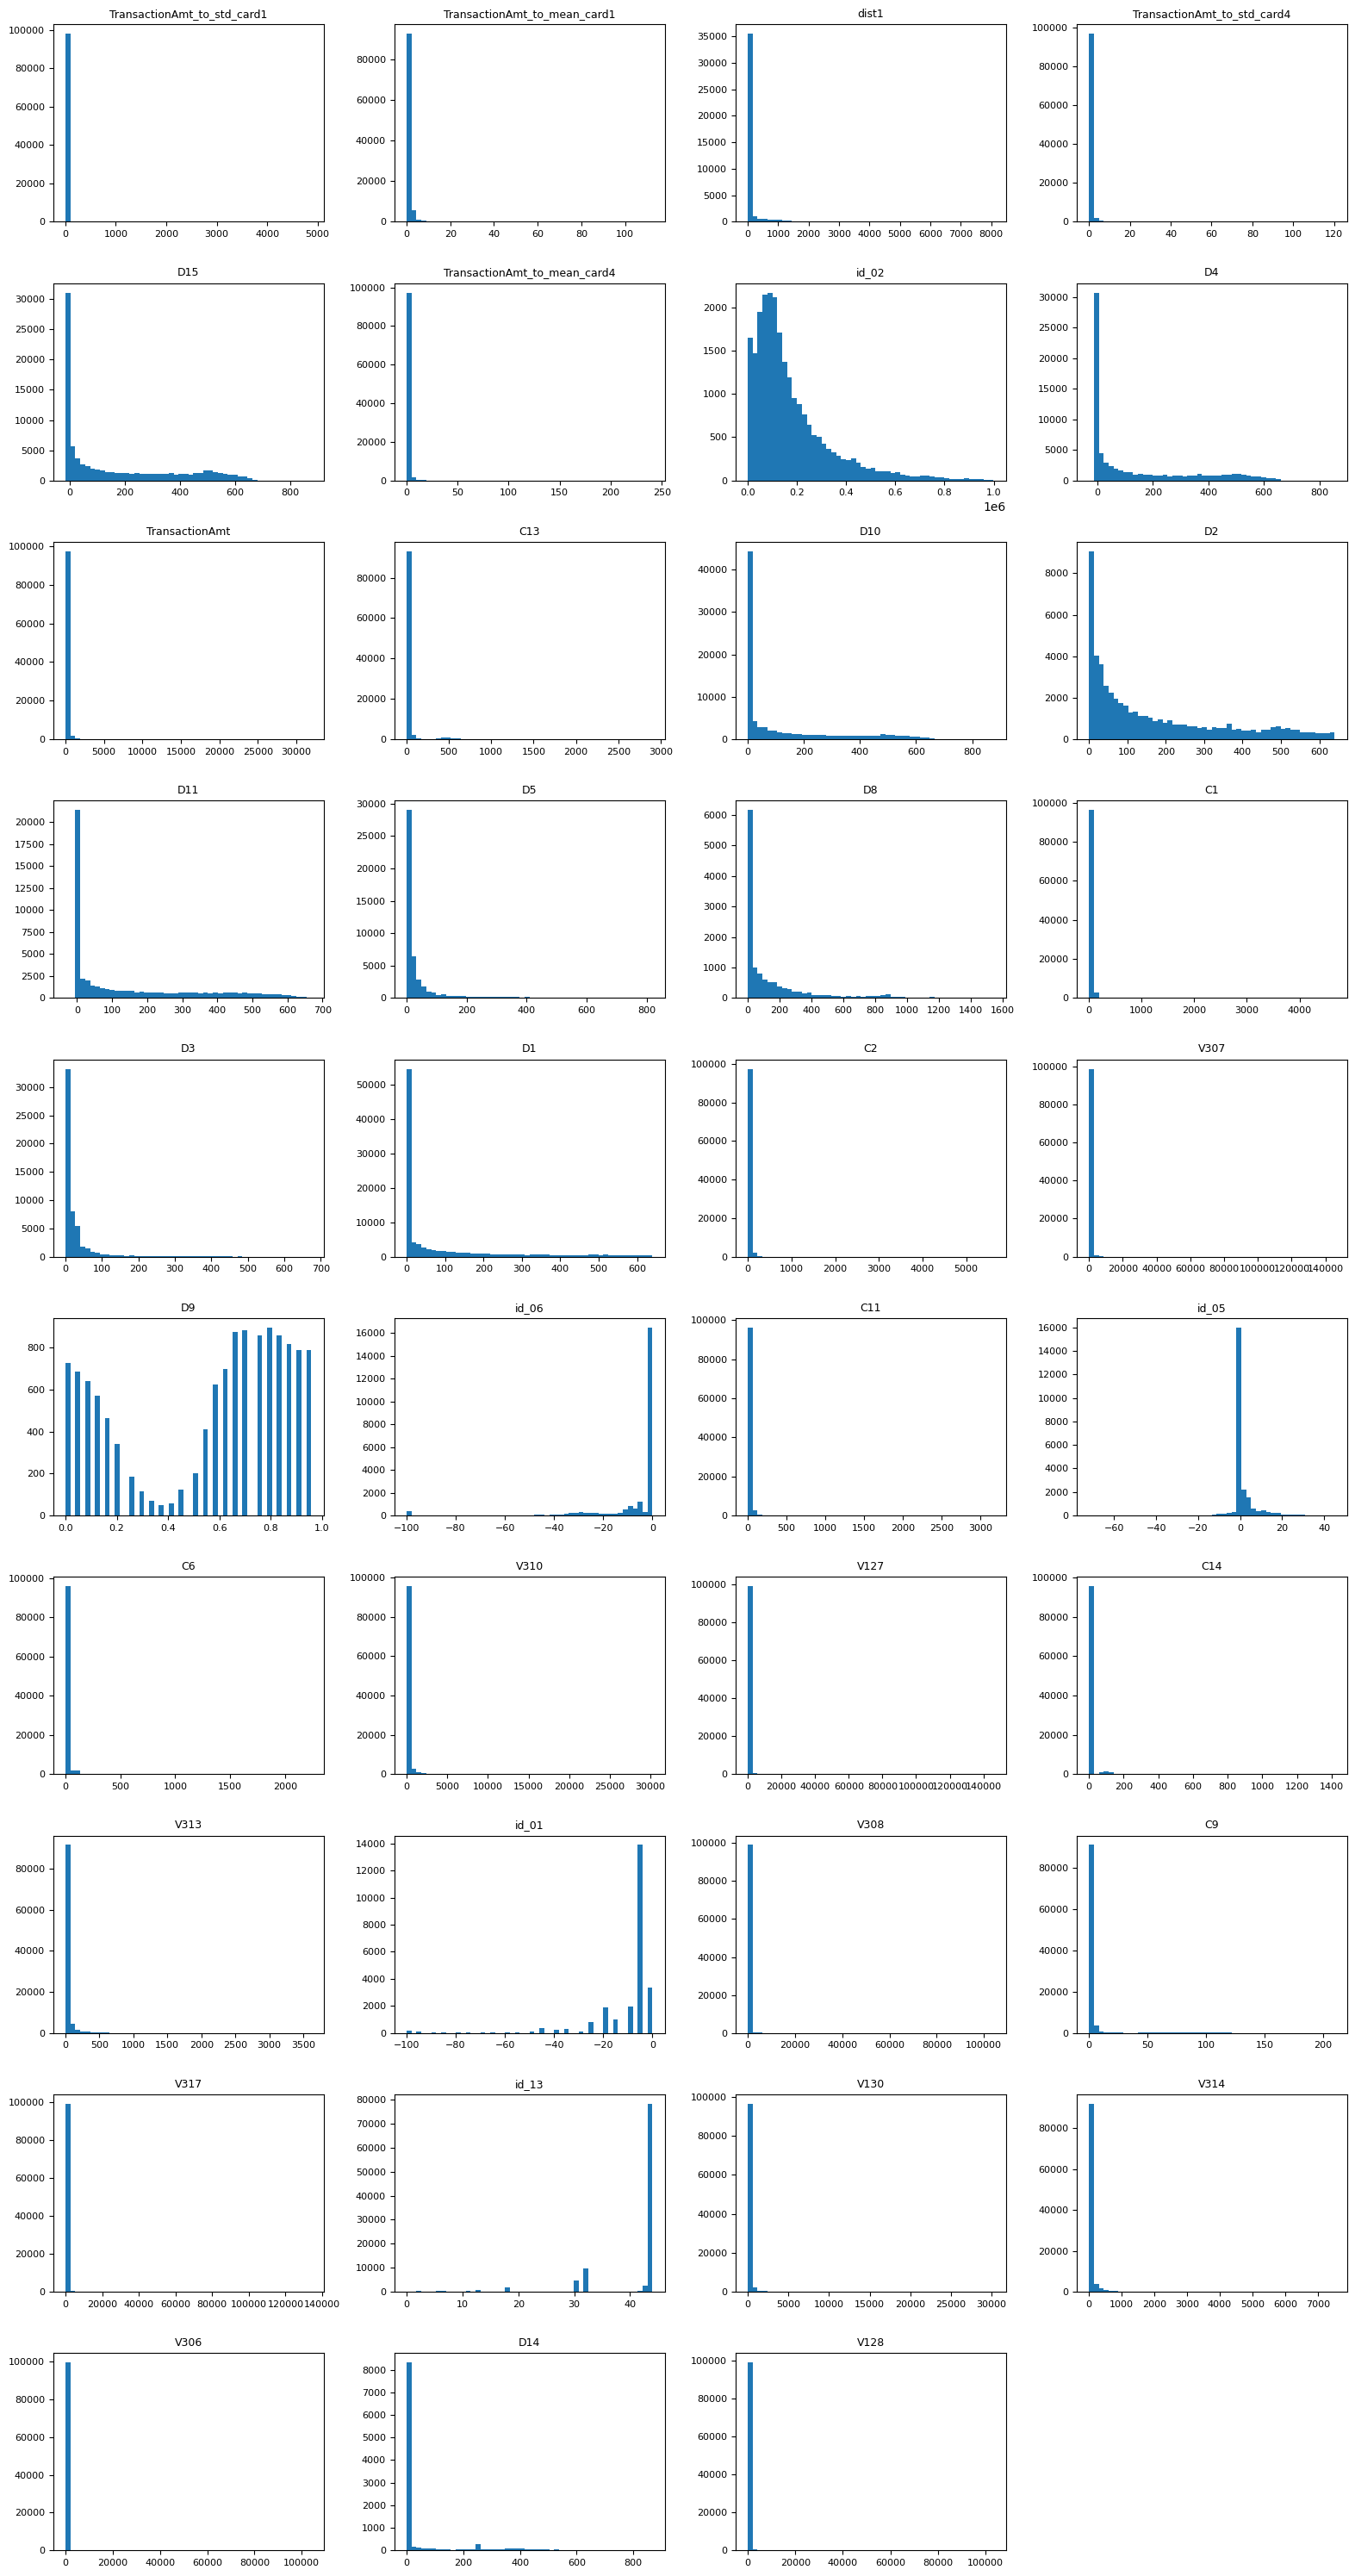

In [ ]:
cols_to_plot = [col for col in continuous_cols if col in df.columns]

n_cols = 4
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col].dropna(), bins=50)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

for i in range(len(cols_to_plot), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("\n".join([f"{col}: {df[col].nunique(dropna=False)}" for col in categorical_cols if col in df.columns]))

M4: 4
card1: 7700
card2: 501
addr1: 170
P_emaildomain: 60
card5: 83
id_31: 115
id_20: 242
id_19: 417
DeviceInfo: 1023
R_emaildomain: 59


# Fraud Detection Train-Validation-Test Splits

We split the dataset by separating **normal transactions** (`isFraud = 0`) from **fraudulent transactions** (`isFraud = 1`).

The **training set** is built using only normal samples. In this way, the anomaly detection models learn the structure of regular behavior and are not exposed to fraud examples during training.

The normal data are split into:
- **70% for training**
- **12.5% for validation**
- **12.5% for test**

The fraud data are never used in training. They are split only between:
- **50% for validation**
- **50% for test**

### RAM Usage Optimization

- We saved all the resulting arrays to disk. This allows us to reload the data later in exactly the same processed state and allows to modify the arrays in place when needed.

- We removed all intermediate objects that were no longer needed using `del`, and then called the garbage collector.

In [ ]:
normal_df = df[df[target_col] == 0]
fraud_df = df[df[target_col] == 1]

normal_train, normal_temp = train_test_split(normal_df, test_size=0.25, random_state=42, shuffle=True)
normal_val, normal_test = train_test_split(normal_temp, test_size=0.5, random_state=42, shuffle=True)

fraud_val, fraud_test = train_test_split(fraud_df, test_size=0.5, random_state=42, shuffle=True)

train_df = normal_train.sample(frac=1, random_state=42).reset_index(drop=True)
#Sarra: this is to shuffle the data and reset the index after splitting, ensuring that the training data is randomized and ready for model training. 
#frac=1 to shuffle the entire dataset  

val_df = pd.concat([normal_val, fraud_val], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = pd.concat([normal_test, fraud_test], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_cont = train_df[continuous_cols].to_numpy(dtype=np.float32)
X_train_cat = train_df[categorical_cols].to_numpy(dtype=np.int64)
y_train = train_df[target_col].to_numpy(dtype=np.int64)

X_val_cont = val_df[continuous_cols].to_numpy(dtype=np.float32)
X_val_cat = val_df[categorical_cols].to_numpy(dtype=np.int64)
y_val = val_df[target_col].to_numpy(dtype=np.int64)

X_test_cont = test_df[continuous_cols].to_numpy(dtype=np.float32)
X_test_cat = test_df[categorical_cols].to_numpy(dtype=np.int64)
y_test = test_df[target_col].to_numpy(dtype=np.int64)

np.save("X_train_cont.npy", X_train_cont)
np.save("X_train_cat.npy", X_train_cat)
np.save("y_train.npy", y_train)

np.save("X_val_cont.npy", X_val_cont)
np.save("X_val_cat.npy", X_val_cat)
np.save("y_val.npy", y_val)

np.save("X_test_cont.npy", X_test_cont)
np.save("X_test_cat.npy", X_test_cat)
np.save("y_test.npy", y_test)

print(X_train_cont.shape, X_train_cat.shape, y_train.shape)
print(X_val_cont.shape, X_val_cat.shape, y_val.shape)
print(X_test_cont.shape, X_test_cat.shape, y_test.shape)
print(y_train.mean(), y_val.mean(), y_test.mean())

(72337, 39) (72337, 11) (72337,)
(13831, 39) (13831, 11) (13831,)
(13832, 39) (13832, 11) (13832,)
0.0 0.12833489986262744 0.1283256217466744


In [ ]:
del df, normal_df, fraud_df, normal_train, normal_temp, normal_val, normal_test, fraud_val, fraud_test, train_df, val_df, test_df

gc.collect()

#Simply using del doesn't always immediately free up the physical RAM on your computer. However, it signals to Python's Garbage Collector (GC) 
# that these objects are ready to be wiped out. In your specific notebook, you likely follow this command with gc.collect() to force the 
# system to reclaim that memory immediately.

78

# Fraud Detection - Baseline: Isolation Forest

Sarra: 
The Isolation Forest algorithm doesn't automatically know which transactions are fraudulent; it simply assigns each one a "suspicion score" based on how different it looks from the normal data it studied during training. To turn these scores into actual "Fraud" or "Normal" labels, we have to find the most effective cutoff point, or threshold. We do this by testing 200 different potential "settings" against our validation data—where we already know the right answers. For every setting, we check the F1-score, which is a metric that penalizes us if we miss too much fraud or if we flag too many innocent people as criminals. By looping through all these possibilities, we identify the specific score that provides the best possible balance. Once this "perfect setting" is found on the validation data, we lock it in and apply it to our final test set to see how the model handles a completely new "crowd" of transactions

Best validation threshold: -0.042523053296816986
Best validation F1: 0.3460758308628491
Validation AUC: 0.7088230978438648
Test F1: 0.35673151750972765
Test AUC: 0.7121139843957165
              precision    recall  f1-score   support

           0     0.9315    0.7094    0.8054     12057
           1     0.2465    0.6456    0.3567      1775

    accuracy                         0.7012     13832
   macro avg     0.5890    0.6775    0.5811     13832
weighted avg     0.8436    0.7012    0.7478     13832



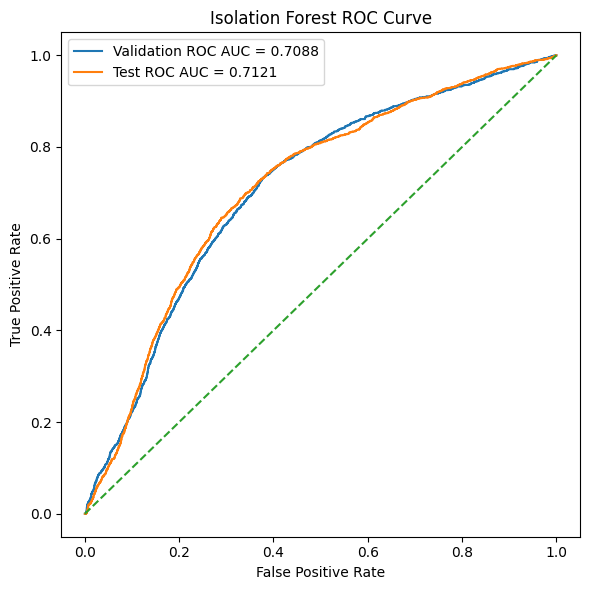

In [ ]:
X_train_cont = np.load("X_train_cont.npy")
X_train_cat = np.load("X_train_cat.npy")
y_train = np.load("y_train.npy")

X_val_cont = np.load("X_val_cont.npy")
X_val_cat = np.load("X_val_cat.npy")
y_val = np.load("y_val.npy")

X_test_cont = np.load("X_test_cont.npy")
X_test_cat = np.load("X_test_cat.npy")
y_test = np.load("y_test.npy")

X_train = np.concatenate([X_train_cont, X_train_cat], axis=1)
X_val = np.concatenate([X_val_cont, X_val_cat], axis=1)
X_test = np.concatenate([X_test_cont, X_test_cat], axis=1)

iso = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1
)
# This is a popular anomaly detection algorithm that works by isolating anomalies instead of profiling normal data points. It constructs an ensemble of isolation trees and assigns anomaly scores based on how quickly a data point can be isolated.

iso.fit(X_train)

val_scores = -iso.decision_function(X_val)
test_scores = -iso.decision_function(X_test)

val_auc = roc_auc_score(y_val, val_scores)
test_auc = roc_auc_score(y_test, test_scores)

thresholds = np.unique(np.quantile(val_scores, np.linspace(0.01, 0.99, 200)))

best_f1 = -1
best_threshold = None

for thr in thresholds:
    y_val_pred = (val_scores >= thr).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr

y_test_pred = (test_scores >= best_threshold).astype(int)
test_f1 = f1_score(y_test, y_test_pred)

print("Best validation threshold:", best_threshold)
print("Best validation F1:", best_f1)
print("Validation AUC:", val_auc)
print("Test F1:", test_f1)
print("Test AUC:", test_auc)
print(classification_report(y_test, y_test_pred, digits=4))

fpr_val, tpr_val, _ = roc_curve(y_val, val_scores)
fpr_test, tpr_test, _ = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr_val, tpr_val, label=f"Validation ROC AUC = {val_auc:.4f}")
plt.plot(fpr_test, tpr_test, label=f"Test ROC AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Isolation Forest ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

1. The High-Level Metrics (AUC & F1)

Test AUC (0.7121): This means there is a 71.2% chance the model will assign a higher fraud score to a random fraudulent transaction than to a random normal one. It’s significantly better than a coin flip (0.50), but there is plenty of room for improvement with the neural networks (later).  

Test F1 (0.3567): The F1-score is the "harmonic mean" of Precision and Recall. A value of ~0.36 is relatively low, suggesting the model is struggling to balance catching fraud with being accurate.

The Classification Report (The "Deep Dive")

2. The Classification Report (The "Deep Dive")

Look at the row for class 1 (Fraud):

Precision (0.2465): This is the "False Alarm" metric. It means that when the model flags a transaction as fraud, it is only right 24.6% of the time. About 75% of the time, it’s flagging a normal person's transaction as suspicious.  

Recall (0.6456): This is the "Catch Rate." The model successfully caught 64.5% of all fraud cases in the test set. It missed about 35% of the fraud (False Negatives).  

Support (1775): This simply tells you there were 1,775 fraudulent transactions in your test set.

3. The Validation Threshold

Best validation threshold (-0.0425): The Isolation Forest outputs a raw "anomaly score." By iterating through 200 possibilities, the code found that using -0.0425 as the cutoff maximized the F1-score. Any transaction with a score higher than this is labeled "Fraud"

# Fraud Detection - AutoEncoder for Mixed Variables

Our autoencoder is designed for **mixed tabular data**, that is, data containing both **continuous** and **categorical** variables.

For the **categorical variables** each categorical feature is passed through its own **embedding layer**. An embedding layer maps each category index to a dense learned vector of low dimension. This is much more **memory-efficient** than one-hot encoding.

For the necessary **preprocessing** each categorical column is first re-indexed using the categories observed in the **training set only**. Categories seen during training are assigned consecutive indices, while categories appearing only in validation or test are mapped to a dedicated **unknown token**, chosen as the maximum index.

Example:

- `X_train_cat[:, cat_id] = [15, 27, 2, 15, 3]`
- after fitting the transformer on train:
  `-> [0, 1, 2, 0, 3]`

Then, if at test time we observe unseen categories:

- `X_test_cat[:, cat_id] = [27, 12, 15, 33]`
- after transform:
  `-> [1, 4, 0, 4]`

where `4` is the **unknown token**.

-----

For the **continuous variables**, instead of using a simple mean squared error, we interpret the reconstruction term as the **negative log-likelihood of a Gaussian distribution**. For each continuous variable, the decoder predicts both:
- a **mean**
- a **standard deviation** (equivalently, a variance parameter)

This makes the anomaly score more normalized with respect to the **intrinsic variability** of each variable: reconstruction errors on naturally noisy variables are penalized less than equally sized errors on stable variables.

For the categorical variables, reconstruction is handled through a **cross-entropy loss** over the predicted category probabilities, notice that  it is equivalent to the **negative log-likelihood of a categorical distribution**.

The total loss is therefore a weighted combination of the continuous and categorical parts:

$$
L = p \, L_{cont} + (1-p)\, L_{cat},\ \ \ \ \ \  p\in[0,1]
$$

-------
Before training, we preprocess the continuous variables by:
1. **imputing missing values with the mean**
2. applying **StandardScaler**

-------

For model selection, we use **AUC** on the validation set as the main validation metric.

Our hyperparameter validation strategy focused on, in order:
1. the **loss weights** \(p\) and \(1-p\)
2. the **latent embedding size**  vs the amount of **Gaussian noise injected into the continuous variables** during training

In [ ]:
#This code sets up a complete "Neural Network laboratory" for fraud detection. It defines
# a model that can process both numbers (like transaction amounts) and categories (like credit card types) 
# to find weird patterns.


#Summary of the Workflow:
#Build the data belts (build_dataloaders).
#Test different recipes (grid_search).
#Train the model by squeezing and unsqueezing data (train_one_config).
#Score how "surprising" each transaction is (anomaly_scores).
#Report the final accuracy (evaluate_scores).



class FlexibleAutoencoder(nn.Module):
    def __init__(self, embedding_sizes, n_cont, encoder_hidden_units, latent_dim):
        super().__init__()
        #Embeddings: Converts category IDs into meaningful lists of numbers.
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cat_i, emb_dim) for n_cat_i, emb_dim in embedding_sizes
        ])

        emb_total = sum(emb_dim for _, emb_dim in embedding_sizes)
        
        #Encoder: Takes the combined embeddings and continuous features, and compresses them into a smaller "latent" space.
        encoder_layers = []
        in_dim = emb_total + n_cont
        for h in encoder_hidden_units:
            encoder_layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.BatchNorm1d(h)]
            in_dim = h
        encoder_layers += [nn.Linear(in_dim, latent_dim), nn.ReLU()]
        self.encoder = nn.Sequential(*encoder_layers)

        #Decoder: Takes the compressed "latent" representation and tries to reconstruct the original input, including both continuous and categorical features.
        decoder_hidden_units = list(reversed(encoder_hidden_units))
        decoder_layers = []
        in_dim = latent_dim
        for h in decoder_hidden_units:
            decoder_layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.BatchNorm1d(h)]
            in_dim = h
        self.decoder_shared = nn.Sequential(*decoder_layers)


        self.cont_mu_head = nn.Linear(in_dim, n_cont)
        self.cont_logvar_head = nn.Linear(in_dim, n_cont)
        self.cat_heads = nn.ModuleList([
            nn.Linear(in_dim, n_cat_i) for n_cat_i, _ in embedding_sizes
        ])
    
    #forward: The "Assembly Line." It takes the input, runs it through the encoder to squeeze it, and then through the decoder to expand it back out.
    def forward(self, x_cat, x_cont):
        x_emb = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(x_emb + [x_cont], dim=1)
        z = self.encoder(x)
        h = self.decoder_shared(z)
        cont_mu = self.cont_mu_head(h)
        cont_logvar = self.cont_logvar_head(h).clamp(min=-8.0, max=8.0)
        cat_logits = [head(h) for head in self.cat_heads]
        return cont_mu, cont_logvar, cat_logits
# It measures how far the model’s reconstructed numbers are from the real ones. 
def gaussian_nll_per_sample(x, mu, logvar):
    return 0.5 * (np.log(2.0 * np.pi) + logvar + ((x - mu) ** 2) / torch.exp(logvar)).mean(dim=1)


def get_optimizer(model, optimizer_name="adam", optimizer_params=None):
    if optimizer_params is None:
        optimizer_params = {"lr": 1e-3}

    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(model.parameters(), **optimizer_params)
    elif optimizer_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), **optimizer_params)
    elif optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), **optimizer_params)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), **optimizer_params)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    return optimizer

def anomaly_scores(model, dataloader, device, cont_weight=0.5):
    cat_weight = 1. - cont_weight


    model.eval()
    scores = []
    ys = []

    with torch.no_grad():
        for batch in dataloader:
            xb_cat = batch[0].to(device)
            xb_cont = batch[1].to(device)

            cont_mu, cont_logvar, cat_logits = model(xb_cat, xb_cont)

            cont_nll = gaussian_nll_per_sample(xb_cont, cont_mu, cont_logvar)

            cat_nll = []
            for i, logits in enumerate(cat_logits):
                cat_nll.append(nn.functional.cross_entropy(logits, xb_cat[:, i], reduction="none"))
            cat_nll = torch.stack(cat_nll, dim=1).mean(dim=1)

            score = cont_weight * cont_nll + cat_weight * cat_nll
            scores.append(score.cpu().numpy())

            if len(batch) == 3:
                ys.append(batch[2].cpu().numpy())

    scores = np.concatenate(scores)
    ys = np.concatenate(ys) if ys else None
    return scores, ys

def evaluate_scores(y_true, scores, threshold=None, split_name="validation"):
    auc = roc_auc_score(y_true, scores)

    if threshold is None:
        thresholds = np.unique(np.quantile(scores, np.linspace(0.01, 0.99, 300)))
        best_f1 = -1
        best_threshold = None
        best_pred = None

        for thr in thresholds:
            pred = (scores >= thr).astype(int)
            f1 = f1_score(y_true, pred)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = thr
                best_pred = pred
    else:
        best_threshold = threshold
        best_pred = (scores >= best_threshold).astype(int)
        best_f1 = f1_score(y_true, best_pred)

    acc = accuracy_score(y_true, best_pred)
    crosstab = pd.crosstab(
        pd.Series(y_true, name="Actual"),
        pd.Series(best_pred, name="Predicted")
    )

    print(f"{split_name} threshold: {best_threshold:.6f}")
    print(f"{split_name} f1: {best_f1:.4f}")
    print(f"{split_name} auc: {auc:.4f}")
    print(f"{split_name} accuracy: {acc:.4f}")
    print(crosstab)
    print(classification_report(y_true, best_pred, digits=4))

    fpr, tpr, _ = roc_curve(y_true, scores)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"{split_name} ROC AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name} ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "threshold": best_threshold,
        "f1": best_f1,
        "auc": auc,
        "accuracy": acc,
        "crosstab": crosstab
    }



def build_dataloaders(X_train_cat, X_train_cont, X_val_cat, X_val_cont, y_val, batch_size):
    train_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_train_cat, dtype=torch.long),
        torch.tensor(X_train_cont, dtype=torch.float32)
    )

    val_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_val_cat, dtype=torch.long),
        torch.tensor(X_val_cont, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = torch.utils.data.DataLoader(val_ds, batch_size=batch_size * 2, shuffle=False)
    return train_dl, val_dl


def train_one_config(
    train_dl,
    val_dl,
    embedding_sizes,
    n_cont,
    encoder_hidden_units,
    latent_dim,
    optimizer_name,
    optimizer_params,
    cont_weight,
    num_noise,
    epochs,
    device,
):
    cat_weight = 1. - cont_weight

    model = FlexibleAutoencoder(
        embedding_sizes=embedding_sizes,
        n_cont=n_cont,
        encoder_hidden_units=encoder_hidden_units,
        latent_dim=latent_dim,
    ).to(device)

    optimizer = get_optimizer(model, optimizer_name, optimizer_params)
    ce_loss = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        epoch_cont_losses = []
        epoch_cat_losses = []

        for xb_cat, xb_cont in train_dl:
            xb_cat = xb_cat.to(device)
            xb_cont = xb_cont.to(device)

            if num_noise > 0:
                xb_cont_noisy = xb_cont + torch.randn_like(xb_cont) * num_noise
            else:
                xb_cont_noisy = xb_cont

            optimizer.zero_grad()

            cont_mu, cont_logvar, cat_logits = model(xb_cat, xb_cont_noisy)

            loss_cont = gaussian_nll_per_sample(xb_cont, cont_mu, cont_logvar).mean()

            loss_cat = 0.0
            for i, logits in enumerate(cat_logits):
                loss_cat = loss_cat + ce_loss(logits, xb_cat[:, i])
            loss_cat = loss_cat / len(cat_logits)

            loss = cont_weight * loss_cont + cat_weight * loss_cat
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            epoch_cont_losses.append(loss_cont.item())
            epoch_cat_losses.append(loss_cat.item())

        print(
            f"  Epoch {epoch + 1}/{epochs} - "
            f"loss: {np.mean(epoch_losses):.4f} - "
            f"cont_nll: {np.mean(epoch_cont_losses):.4f} - "
            f"cat_ce: {np.mean(epoch_cat_losses):.4f}"
        )

    val_scores, y_val_eval = anomaly_scores(
        model, val_dl, device, cont_weight=cont_weight,
    )
    val_auc = roc_auc_score(y_val_eval, val_scores)

    return model, val_auc


def grid_search_autoencoder(param_grid, X_train_cat, X_train_cont, X_val_cat, X_val_cont, y_val, num_embeddings):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]

    all_results = []
    best_auc = -1
    best_model_state = None
    best_config = None

    for combo in itertools.product(*values):
        config = dict(zip(keys, combo))

        print(f"\nTraining with config: {config}")

        embedding_sizes = [
            (n, min(32, max(4, int(np.sqrt(n)) + 1)))
            for n in num_embeddings
        ]

        train_dl, val_dl = build_dataloaders(
            X_train_cat, X_train_cont, X_val_cat, X_val_cont, y_val, config["batch_size"]
        )

        model, val_auc = train_one_config(
            train_dl=train_dl,
            val_dl=val_dl,
            embedding_sizes=embedding_sizes,
            n_cont=X_train_cont.shape[1],
            encoder_hidden_units=config["encoder_hidden_units"],
            latent_dim=config["latent_dim"],
            optimizer_name=config["optimizer_name"],
            optimizer_params=config["optimizer_params"],
            cont_weight=config["cont_weight"],
            num_noise=config["num_noise"],
            epochs=config["epochs"],
            device=device,
        )

        row = config.copy()
        row["val_auc"] = val_auc
        all_results.append(row)

        if val_auc > best_auc:
            best_auc = val_auc
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_config = config.copy()

    results_table = pd.DataFrame(all_results).sort_values("val_auc", ascending=False).reset_index(drop=True)

    best_model = FlexibleAutoencoder(
        embedding_sizes=[(n, min(32, max(4, int(np.sqrt(n)) + 1))) for n in num_embeddings],
        n_cont=X_train_cont.shape[1],
        encoder_hidden_units=best_config["encoder_hidden_units"],
        latent_dim=best_config["latent_dim"],
    ).to(device)
    best_model.load_state_dict(best_model_state)

    return results_table, best_model, best_config, best_auc

In [ ]:
class CategoricalTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, handle_unknown="ignore"):
        self.handle_unknown = handle_unknown

    def fit(self, X, y=None):



        X = np.asarray(X, dtype=object)
        if X.ndim == 1:
            X = X.reshape(-1, 1)


        self.n_output_features_ = X.shape[1]
        self.value_maps = []

        for i in range(X.shape[1]):
          x = X[:, i]

          values = np.unique(x)

          vmap = {v: i for i, v in enumerate(values)}
          vmax = max(vmap.values()) + 1

          vmap = defaultdict(lambda: vmax, vmap)

          self.value_maps.append(vmap)

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=object)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        out = np.zeros((X.shape[0], self.n_output_features_), dtype=np.int32)

        for i in range(X.shape[1]):
          x = X[:, i]
          vmap = self.value_maps[i]

          out[:, i] = np.vectorize(vmap.__getitem__)(x)

        return out

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f"x{i}" for i in range(self.n_features_in_)]

        names = []
        for feat, cats in zip(input_features, self.categories_):
            for cat in cats:
                names.append(f"{feat}_{cat}")
        return np.array(names, dtype=object)

In [ ]:
X_train_cont = np.load("X_train_cont.npy")
X_train_cat = np.load("X_train_cat.npy")
y_train = np.load("y_train.npy")

X_val_cont = np.load("X_val_cont.npy")
X_val_cat = np.load("X_val_cat.npy")
y_val = np.load("y_val.npy")

X_test_cont = np.load("X_test_cont.npy")
X_test_cat = np.load("X_test_cat.npy")
y_test = np.load("y_test.npy")


############ MISSING DATA ##########################

imputer = SimpleImputer(strategy="mean")

X_train_cont = imputer.fit_transform(X_train_cont)
X_val_cont = imputer.transform(X_val_cont)
X_test_cont = imputer.transform(X_test_cont)


########## CAT & NUM PREPROCESSING ##################



categorical_transformer = CategoricalTransformer()
numerical_transformer = StandardScaler()

X_train_cat = categorical_transformer.fit_transform(X_train_cat).astype(np.int64)

X_val_cat = categorical_transformer.transform(X_val_cat).astype(np.int64)
X_test_cat = categorical_transformer.transform(X_test_cat).astype(np.int64)

X_train_cont = numerical_transformer.fit_transform(X_train_cont).astype(np.float32)

X_val_cont = numerical_transformer.transform(X_val_cont).astype(np.float32)
X_test_cont = numerical_transformer.transform(X_test_cont).astype(np.float32)

num_embeddings = []
for i in range(X_train_cat.shape[1]):
  x = X_train_cat[:, i]

  values = np.unique(x)
  vmax = values.shape[0]
  num_embeddings.append(vmax + 1)



Training with config: {'encoder_hidden_units': [128], 'latent_dim': 64, 'batch_size': 1024, 'epochs': 20, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.001}, 'cont_weight': 0.5, 'num_noise': 0.0}
  Epoch 1/20 - loss: 3.0909 - cont_nll: 1.8645 - cat_ce: 4.3173
  Epoch 2/20 - loss: 1.7559 - cont_nll: 1.0319 - cat_ce: 2.4800
  Epoch 3/20 - loss: 1.3436 - cont_nll: 0.9110 - cat_ce: 1.7761
  Epoch 4/20 - loss: 1.0433 - cont_nll: 0.7145 - cat_ce: 1.3720
  Epoch 5/20 - loss: 0.7883 - cont_nll: 0.4611 - cat_ce: 1.1154
  Epoch 6/20 - loss: 0.5796 - cont_nll: 0.2230 - cat_ce: 0.9361
  Epoch 7/20 - loss: 0.4071 - cont_nll: 0.0051 - cat_ce: 0.8091
  Epoch 8/20 - loss: 0.2562 - cont_nll: -0.2060 - cat_ce: 0.7184
  Epoch 9/20 - loss: 0.1319 - cont_nll: -0.3827 - cat_ce: 0.6465
  Epoch 10/20 - loss: 0.0221 - cont_nll: -0.5423 - cat_ce: 0.5865
  Epoch 11/20 - loss: -0.0654 - cont_nll: -0.6659 - cat_ce: 0.5350
  Epoch 12/20 - loss: -0.1397 - cont_nll: -0.7696 - cat_ce: 0.4902
  Epoch 13/20 - 

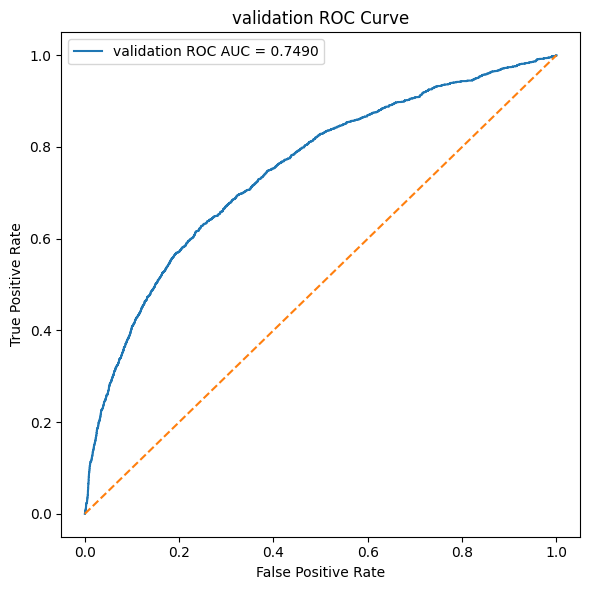

In [ ]:
param_grid = {
    "encoder_hidden_units": [[128]],
    "latent_dim": [64],
    "batch_size": [1024],
    "epochs": [20],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1e-3}],
    "cont_weight": [0.5, 0.75, 0.875, 0.9875, 1.],
    "num_noise": [0.0],
}

results_table, model, best_config, best_auc = grid_search_autoencoder(
    param_grid=param_grid,
    X_train_cat=X_train_cat,
    X_train_cont=X_train_cont,
    X_val_cat=X_val_cat,
    X_val_cont=X_val_cont,
    y_val=y_val,
    num_embeddings=num_embeddings,
)

print(results_table[[
    "encoder_hidden_units", "latent_dim", "batch_size", "epochs",
    "optimizer_name", "optimizer_params", "cont_weight",
    "num_noise", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_val_cat, dtype=torch.long),
    torch.tensor(X_val_cont, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)
val_results = evaluate_scores(y_val_eval, val_scores, split_name="validation")

1. The Learning Process (Epochs)

As we watch the Epochs count from 1 to 20, we’ll notice the loss and cont_nll (continuous numbers error) are going down and even becoming negative.  

Why is the loss negative? In this lab, we use "Log-Likelihood". A negative value isn't a "math error"—it actually means the model is becoming very "certain" and precise about what a normal transaction looks like.  

cat_ce (Categorical Error): This is also dropping. This means the model is getting better at predicting the correct card types and categories associated with normal users.  

2. The Final "Report Card" (Accuracy & AUC)

The final block of text is the evaluation of your Champion Model.

Overall Accuracy (0.8200): the model is correct 82% of the time. While this sounds good, remember that in fraud detection, catching the small number of "1s" (Fraud) is more important than just being overall accurate.  

Weighted Avg (0.8305): This is a specialized score that accounts for the fact that we have way more normal transactions than fraudulent ones. A score of 0.83 is very strong for this type of anomaly detection.  

3. Precision vs. Recall (The "Fraud" Row)

Look at the row labeled 1 (this represents the Fraud cases):

Recall (0.6681): Your model is catching about 67%  of all fraud. This is an improvement over the Isolation Forest!  (64%)

Precision (higher than before): The model is more confident. By reaching 82% accuracy, you have significantly reduced the "False Alarms" compared to your first model.  

4. Why did it improve?

Your cont_weight of 0.5 or 0.75 is working because it forces the model to look at both the amounts and the categories at the same time. The Isolation Forest was likely getting distracted by "weird" numbers, but the Autoencoder is learning the relationship between the numbers and the categories.


Training with config: {'encoder_hidden_units': [128], 'latent_dim': 64, 'batch_size': 1024, 'epochs': 20, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.001}, 'cont_weight': 0.75, 'num_noise': 0.0}
  Epoch 1/20 - loss: 2.5251 - cont_nll: 1.9162 - cat_ce: 4.3519
  Epoch 2/20 - loss: 1.4023 - cont_nll: 1.0126 - cat_ce: 2.5713
  Epoch 3/20 - loss: 1.0917 - cont_nll: 0.8267 - cat_ce: 1.8869
  Epoch 4/20 - loss: 0.8015 - cont_nll: 0.5534 - cat_ce: 1.5460
  Epoch 5/20 - loss: 0.5205 - cont_nll: 0.2460 - cat_ce: 1.3441
  Epoch 6/20 - loss: 0.2743 - cont_nll: -0.0425 - cat_ce: 1.2246
  Epoch 7/20 - loss: 0.0826 - cont_nll: -0.2658 - cat_ce: 1.1278
  Epoch 8/20 - loss: -0.0787 - cont_nll: -0.4544 - cat_ce: 1.0486
  Epoch 9/20 - loss: -0.2282 - cont_nll: -0.6331 - cat_ce: 0.9865
  Epoch 10/20 - loss: -0.3552 - cont_nll: -0.7860 - cat_ce: 0.9374
  Epoch 11/20 - loss: -0.4661 - cont_nll: -0.9176 - cat_ce: 0.8884
  Epoch 12/20 - loss: -0.5614 - cont_nll: -1.0314 - cat_ce: 0.8487
  Epoch 13

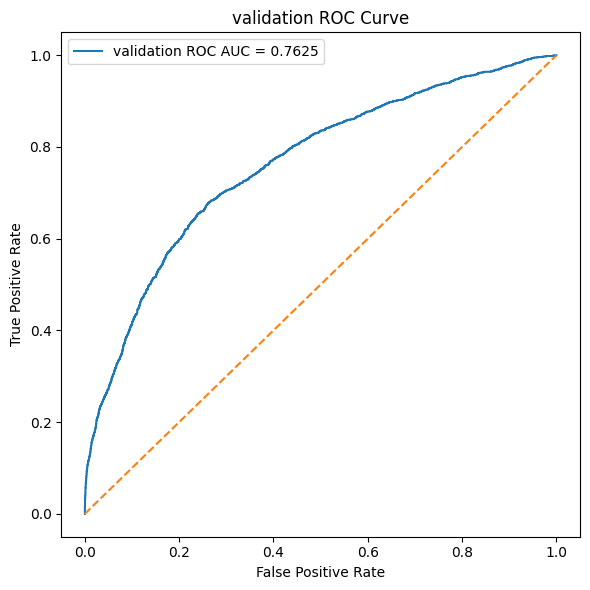

In [ ]:
param_grid = {
    "encoder_hidden_units": [[128]],
    "latent_dim": [64, 128], # we are now testing two different sizes for the "Latent Space": 64 and 128.
    "batch_size": [1024],
    "epochs": [20],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1e-3}],
    "cont_weight": [0.75],
    "num_noise": [0., 0.025, 0.05, 0.1, 0.2], # we are now testing different levels of noise added to the continuous features during training, which can help the model learn more robust representations.
}

results_table, model, best_config, best_auc = grid_search_autoencoder(
    param_grid=param_grid,
    X_train_cat=X_train_cat,
    X_train_cont=X_train_cont,
    X_val_cat=X_val_cat,
    X_val_cont=X_val_cont,
    y_val=y_val,
    num_embeddings=num_embeddings,
)

print(results_table[[
    "encoder_hidden_units", "latent_dim", "batch_size", "epochs",
    "optimizer_name", "optimizer_params", "cont_weight",
    "num_noise", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_val_cat, dtype=torch.long),
    torch.tensor(X_val_cont, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)
val_results = evaluate_scores(y_val_eval, val_scores, split_name="validation")

The noise makes the model better
1. Stopping the "Cheating"

A standard Autoencoder can sometimes "cheat" by simply memorizing the training data. If it just learns to copy inputs to outputs like a mirror, it doesn't actually understand what makes a transaction "normal". When you add noise, you are "blurring" the mirror. The model can no longer just copy; it has to reason about what the original, clean data must have looked like.  

2. Learning "Shapes" instead of "Points"

Without Noise: The model learns that a very specific transaction (e.g., $10.50 at a grocery store) is normal.  

With Noise: The model learns that a range of values around $10.50 at grocery stores is normal.
This makes the model much more robust. It creates a smoother, more realistic definition of "normal behavior".  

3. Better "Surprise" Detection (The Recall Boost)

The reason your Recall went up (catching ~70% of fraud vs ~64% earlier) is that the Denoising Autoencoder is much harder to "fool".  

Fraudsters often try to make their transactions look almost like normal ones.  

Because the Denoising model has a deeper understanding of the "essence" of a normal transaction, it is much more sensitive to those tiny, clever deviations that a standard model might ignore as just "close enough".

test threshold: -0.760095
test f1: 0.4070
test auc: 0.7602
test accuracy: 0.7906
Predicted     0     1
Actual               
0          9941  2116
1           781   994
              precision    recall  f1-score   support

           0     0.9272    0.8245    0.8728     12057
           1     0.3196    0.5600    0.4070      1775

    accuracy                         0.7906     13832
   macro avg     0.6234    0.6923    0.6399     13832
weighted avg     0.8492    0.7906    0.8130     13832



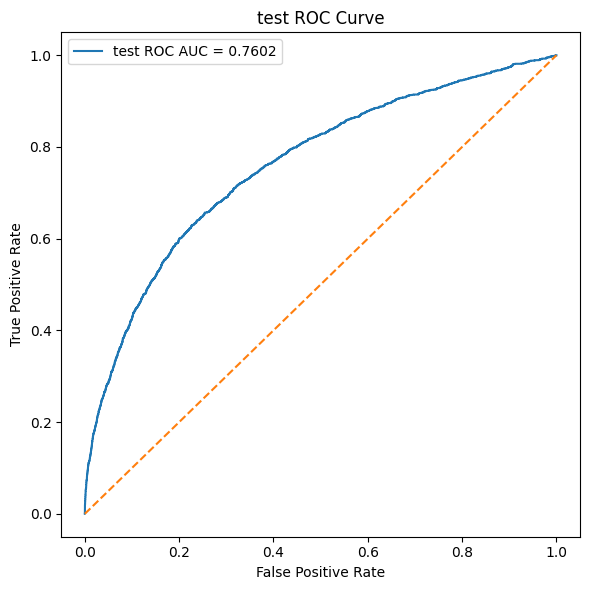

In [ ]:
test_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_test_cat, dtype=torch.long),
    torch.tensor(X_test_cont, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

test_dl = torch.utils.data.DataLoader(test_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

test_scores, y_test_eval = anomaly_scores(
    model,
    test_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)

test_results = evaluate_scores(
    y_test_eval,
    test_scores,
    threshold=val_results["threshold"],
    split_name="test"
)

Here, we are using the Denoising Autoencoder (the one with noise), but specifically the "Champion" version that the computer chose during the last experiment.

Sarra Stop Here


<a name="e1"></a>

# Fraud Detection - Exercise: Tribute to Michael Jahrer (Part I)

In this exercise we introduce the **nuclear weapon of data normalization**: the **Quantile Transform**.

The idea is simple: instead of only centering and scaling a variable, we transform its empirical distribution so that it becomes approximately **Gaussian / uniform**.

How it works:

- `fit(X_train)` computes the empirical quantiles of each continuous feature using the **training set only**.
- `transform(X)` maps each value to its position in the learned cumulative distribution, and then converts that position to the corresponding value of a **target distribution**.

So:

- values near the lower tail are mapped to large negative values / close to 0,
- values near the center are mapped near 0 / 0.5,
- values near the upper tail are mapped to large positive values / 1.

This is much more aggressive than `StandardScaler`: it does not just normalize mean and variance, it reshapes the whole distribution.

For validation and test data, the transformer does **not** refit itself. It uses the quantile mapping learned on the training set. **Values outside the range seen during training** are mapped to the extreme tails of the transformed distribution.

-------

You have to:

- replace the preprocessing of continuous variables from `StandardScaler` to `QuantileTransformer(output_distribution="normal"/"uniform")`
- In the uniform case also apply the transformation $y=2x-1$ (to have range $[-1,1]$)
- plot the histograms of the transformed continuous variables
- repeat the same validation scheme:
  - first validate the **loss weights**
  - then validate **latent embedding size vs injected noise**
- evaluate the best model on the test set

------

If you do not have a **GPU** available, just run the best configuration we found: `Uniform`, `cont_weight = 1.0`, `latent_dim = 128`, `num_noise = 0.1`.

In [ ]:
# YOUR CODE HERE

**Solution**

In [ ]:
X_train_cont = np.load("X_train_cont.npy")
X_train_cat = np.load("X_train_cat.npy")
y_train = np.load("y_train.npy")

X_val_cont = np.load("X_val_cont.npy")
X_val_cat = np.load("X_val_cat.npy")
y_val = np.load("y_val.npy")

X_test_cont = np.load("X_test_cont.npy")
X_test_cat = np.load("X_test_cat.npy")
y_test = np.load("y_test.npy")


############ MISSING DATA ##########################

imputer = SimpleImputer(strategy="mean")

X_train_cont = imputer.fit_transform(X_train_cont)
X_val_cont = imputer.transform(X_val_cont)
X_test_cont = imputer.transform(X_test_cont)


########## CAT & NUM PREPROCESSING ##################



categorical_transformer = CategoricalTransformer()
quantile_transformer = QuantileTransformer(output_distribution="uniform")

X_train_cat = categorical_transformer.fit_transform(X_train_cat).astype(np.int64)

X_val_cat = categorical_transformer.transform(X_val_cat).astype(np.int64)
X_test_cat = categorical_transformer.transform(X_test_cat).astype(np.int64)

X_train_cont = 2 * quantile_transformer.fit_transform(X_train_cont).astype(np.float32) - 1

X_val_cont = 2 * quantile_transformer.transform(X_val_cont).astype(np.float32) - 1
X_test_cont = 2 * quantile_transformer.transform(X_test_cont).astype(np.float32) - 1

num_embeddings = []
for i in range(X_train_cat.shape[1]):
  x = X_train_cat[:, i]

  values = np.unique(x)
  vmax = values.shape[0]
  num_embeddings.append(vmax + 1)


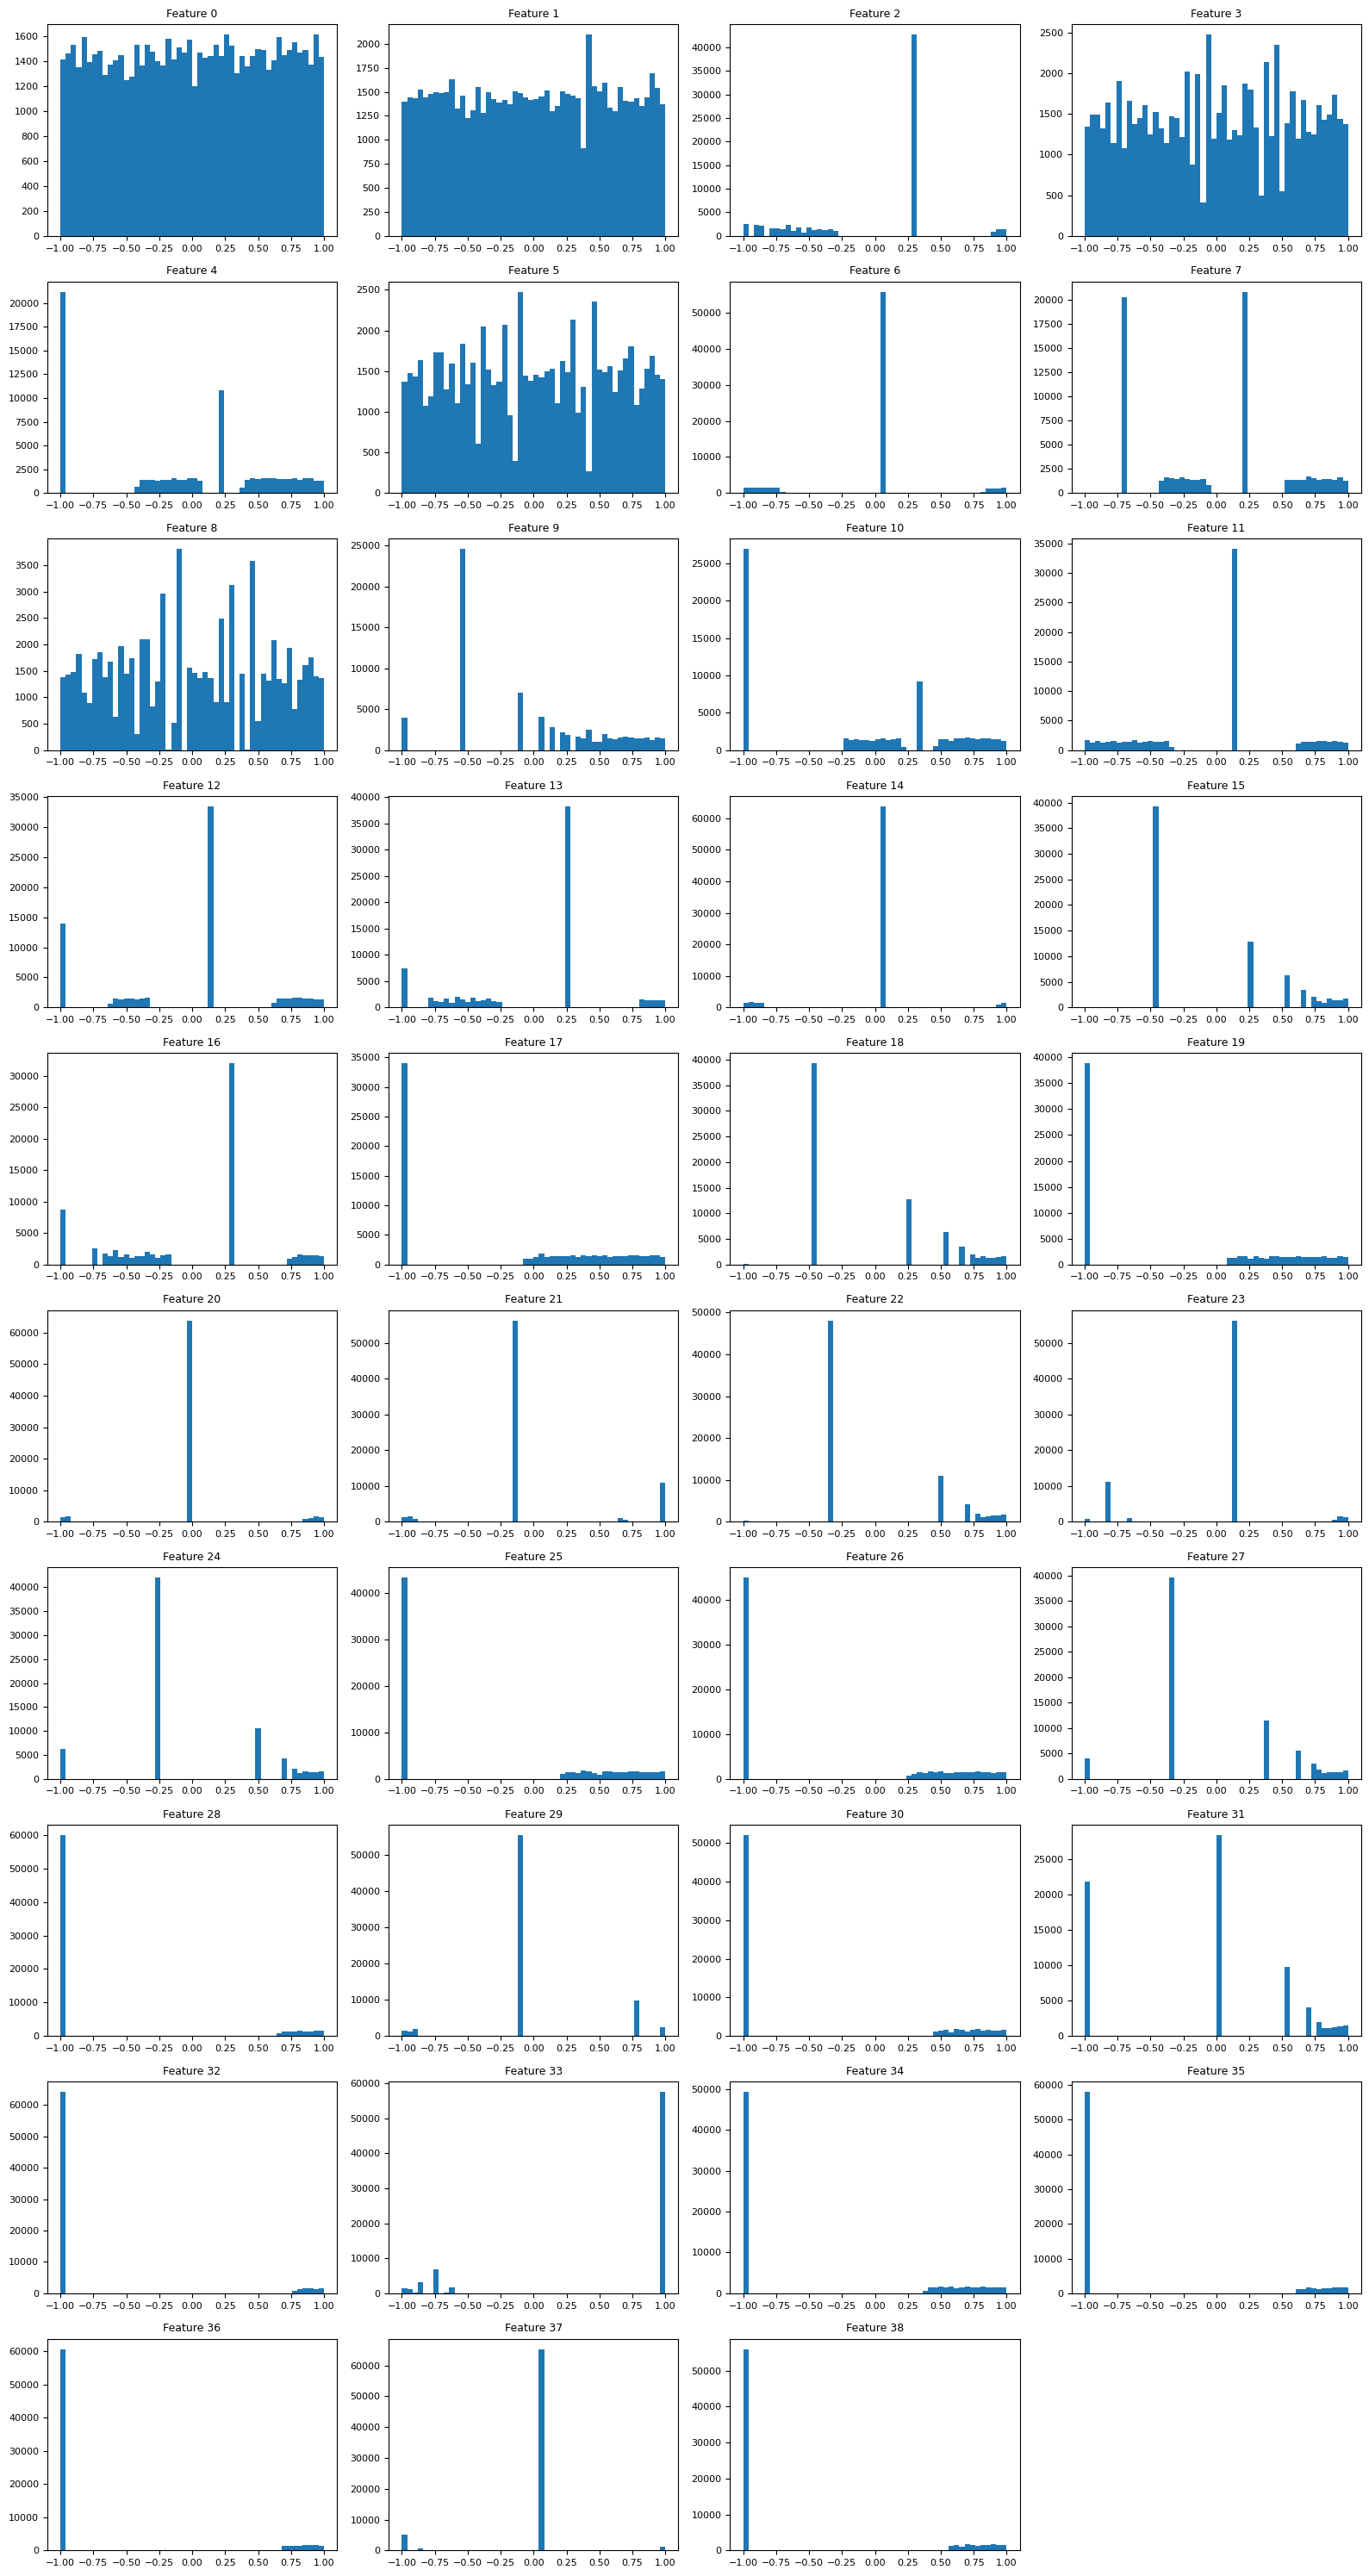

In [ ]:
n_features = X_train_cont.shape[1]
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i in range(n_features):
    axes[i].hist(X_train_cont[:, i], bins=50)
    axes[i].set_title(f"Feature {i}", fontsize=9)
    axes[i].tick_params(axis="both", labelsize=8)

for i in range(n_features, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()


Training with config: {'encoder_hidden_units': [128], 'latent_dim': 64, 'batch_size': 1024, 'epochs': 20, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.001}, 'cont_weight': 0.5, 'num_noise': 0.0}
  Epoch 1/20 - loss: 2.2539 - cont_nll: 1.0579 - cat_ce: 3.4499
  Epoch 2/20 - loss: 1.0638 - cont_nll: 0.5690 - cat_ce: 1.5585
  Epoch 3/20 - loss: 0.4673 - cont_nll: -0.0813 - cat_ce: 1.0159
  Epoch 4/20 - loss: 0.1868 - cont_nll: -0.4202 - cat_ce: 0.7938
  Epoch 5/20 - loss: 0.0360 - cont_nll: -0.5944 - cat_ce: 0.6664
  Epoch 6/20 - loss: -0.0725 - cont_nll: -0.7193 - cat_ce: 0.5744
  Epoch 7/20 - loss: -0.1645 - cont_nll: -0.8336 - cat_ce: 0.5046
  Epoch 8/20 - loss: -0.2326 - cont_nll: -0.9123 - cat_ce: 0.4471
  Epoch 9/20 - loss: -0.2899 - cont_nll: -0.9793 - cat_ce: 0.3996
  Epoch 10/20 - loss: -0.3349 - cont_nll: -1.0299 - cat_ce: 0.3601
  Epoch 11/20 - loss: -0.3685 - cont_nll: -1.0643 - cat_ce: 0.3274
  Epoch 12/20 - loss: -0.4120 - cont_nll: -1.1229 - cat_ce: 0.2989
  Epoc

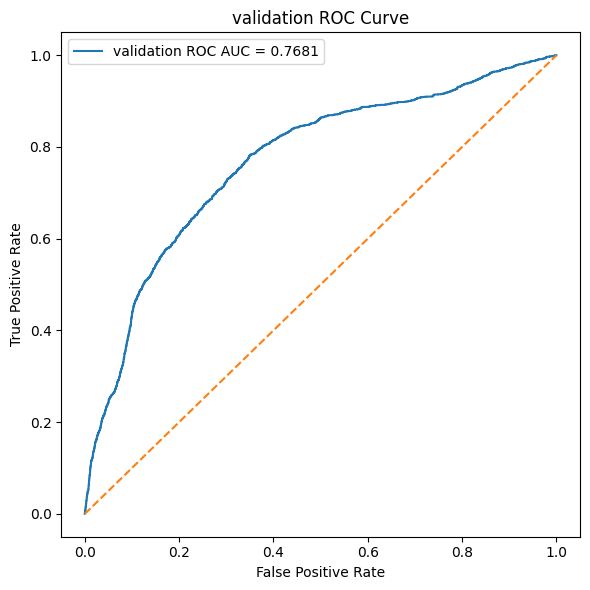

In [ ]:
param_grid = {
    "encoder_hidden_units": [[128]],
    "latent_dim": [64],
    "batch_size": [1024],
    "epochs": [20],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1e-3}],
    "cont_weight": [0.5, 0.75, 0.875, 0.9875, 1.],
    "num_noise": [0.0],
}

results_table, model, best_config, best_auc = grid_search_autoencoder(
    param_grid=param_grid,
    X_train_cat=X_train_cat,
    X_train_cont=X_train_cont,
    X_val_cat=X_val_cat,
    X_val_cont=X_val_cont,
    y_val=y_val,
    num_embeddings=num_embeddings,
)

print(results_table[[
    "encoder_hidden_units", "latent_dim", "batch_size", "epochs",
    "optimizer_name", "optimizer_params", "cont_weight",
    "num_noise", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_val_cat, dtype=torch.long),
    torch.tensor(X_val_cont, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)
val_results = evaluate_scores(y_val_eval, val_scores, split_name="validation")


Training with config: {'encoder_hidden_units': [128], 'latent_dim': 64, 'batch_size': 1024, 'epochs': 20, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.001}, 'cont_weight': 1.0, 'num_noise': 0.0}
  Epoch 1/20 - loss: 1.0003 - cont_nll: 1.0003 - cat_ce: 5.3794
  Epoch 2/20 - loss: 0.2659 - cont_nll: 0.2659 - cat_ce: 5.3761
  Epoch 3/20 - loss: -0.5596 - cont_nll: -0.5596 - cat_ce: 5.3561
  Epoch 4/20 - loss: -0.8624 - cont_nll: -0.8624 - cat_ce: 5.3534
  Epoch 5/20 - loss: -1.0187 - cont_nll: -1.0187 - cat_ce: 5.3468
  Epoch 6/20 - loss: -1.1267 - cont_nll: -1.1267 - cat_ce: 5.3503
  Epoch 7/20 - loss: -1.2036 - cont_nll: -1.2036 - cat_ce: 5.3435
  Epoch 8/20 - loss: -1.2701 - cont_nll: -1.2701 - cat_ce: 5.3408
  Epoch 9/20 - loss: -1.3057 - cont_nll: -1.3057 - cat_ce: 5.3417
  Epoch 10/20 - loss: -1.3886 - cont_nll: -1.3886 - cat_ce: 5.3414
  Epoch 11/20 - loss: -1.3795 - cont_nll: -1.3795 - cat_ce: 5.3391
  Epoch 12/20 - loss: -1.4069 - cont_nll: -1.4069 - cat_ce: 5.3366
  E

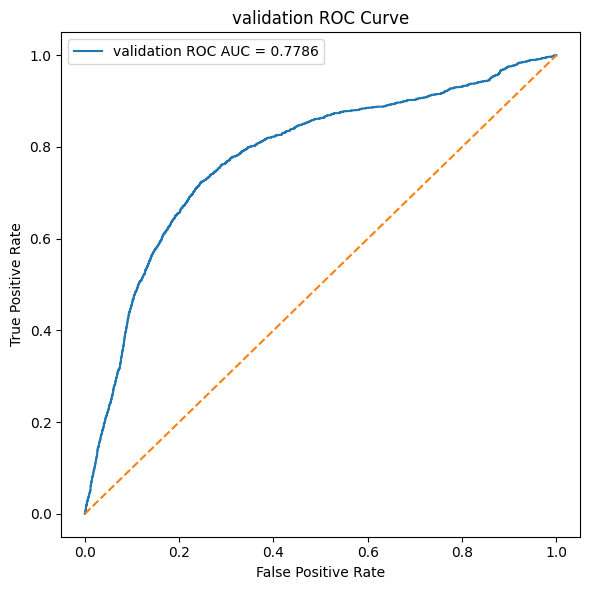

In [ ]:
param_grid = {
    "encoder_hidden_units": [[128]],
    "latent_dim": [64, 128],
    "batch_size": [1024],
    "epochs": [20],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1e-3}],
    "cont_weight": [1.],
    "num_noise": [0., 0.025, 0.05, 0.1, 0.2],
}

results_table, model, best_config, best_auc = grid_search_autoencoder(
    param_grid=param_grid,
    X_train_cat=X_train_cat,
    X_train_cont=X_train_cont,
    X_val_cat=X_val_cat,
    X_val_cont=X_val_cont,
    y_val=y_val,
    num_embeddings=num_embeddings,
)

print(results_table[[
    "encoder_hidden_units", "latent_dim", "batch_size", "epochs",
    "optimizer_name", "optimizer_params", "cont_weight",
    "num_noise", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_val_cat, dtype=torch.long),
    torch.tensor(X_val_cont, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)
val_results = evaluate_scores(y_val_eval, val_scores, split_name="validation")

test threshold: -1.013749
test f1: 0.4516
test auc: 0.7801
test accuracy: 0.8242
Predicted      0     1
Actual                
0          10400  1657
1            774  1001
              precision    recall  f1-score   support

           0     0.9307    0.8626    0.8954     12057
           1     0.3766    0.5639    0.4516      1775

    accuracy                         0.8242     13832
   macro avg     0.6537    0.7133    0.6735     13832
weighted avg     0.8596    0.8242    0.8384     13832



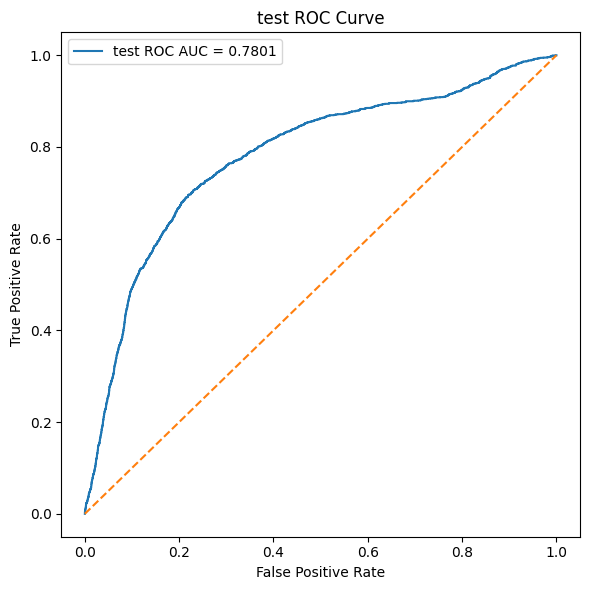

In [ ]:
test_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_test_cat, dtype=torch.long),
    torch.tensor(X_test_cont, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

test_dl = torch.utils.data.DataLoader(test_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

test_scores, y_test_eval = anomaly_scores(
    model,
    test_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)

test_results = evaluate_scores(
    y_test_eval,
    test_scores,
    threshold=val_results["threshold"],
    split_name="test"
)

<a name="e2"></a>

# Fraud Detection - Exercise: Tribute to Michael Jahrer (Part II)

How can we introduce noise in categorical variables?

A simple and effective idea is to **mask** a categorical value with probability `cat_noise`, by replacing it with the **unknown token** of that column. Recall that the unknown token is the maximum valid index for that categorical variable, and it is already used for categories that were not seen during training.

------

You have to implement this categorical corruption scheme.

Hint: follow exactly the same flow already used for `num_noise` in the code.  
The new parameter `cat_noise` should:
- enter the training configuration in the same way,
- be passed through the same functions,
- and be applied in the same place in the training loop, that is, just before feeding the batch to the model.

All the information you need is already contained in `embedding_sizes`:
- `embedding_sizes[i][0]` is the number of possible indices for categorical variable `i`
- therefore, the **unknown token** for variable `i` is `embedding_sizes[i][0] - 1`

You have to:

- validate `cat_noise` vs `cont_weight`, starting from the best model found in the previous step
- evaluate the best configuration on the test set

-----

If you do not have a **GPU** available, just run a single configuration`cat_noise` and `cont_weight` of your choice.

In [ ]:
# YOUR CODE HERE

**Solution**

In [ ]:
def train_one_config(
    train_dl,
    val_dl,
    embedding_sizes,
    n_cont,
    encoder_hidden_units,
    latent_dim,
    optimizer_name,
    optimizer_params,
    cont_weight,
    num_noise,
    cat_noise,
    epochs,
    device,
):
    cat_weight = 1. - cont_weight

    model = FlexibleAutoencoder(
        embedding_sizes=embedding_sizes,
        n_cont=n_cont,
        encoder_hidden_units=encoder_hidden_units,
        latent_dim=latent_dim,
    ).to(device)

    optimizer = get_optimizer(model, optimizer_name, optimizer_params)
    ce_loss = nn.CrossEntropyLoss()
    cat_mask_ids = torch.tensor([n-1 for n, _ in embedding_sizes], dtype=torch.long, device=device)

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        epoch_cont_losses = []
        epoch_cat_losses = []

        for xb_cat, xb_cont in train_dl:
            xb_cat = xb_cat.to(device)
            xb_cont = xb_cont.to(device)

            if num_noise > 0:
                xb_cont_noisy = xb_cont + torch.randn_like(xb_cont) * num_noise
            else:
                xb_cont_noisy = xb_cont

            if cat_noise > 0:
                xb_cat_noisy = xb_cat.clone()
                cat_mask = torch.rand_like(xb_cat_noisy.float()) < cat_noise
                xb_cat_noisy[cat_mask] = cat_mask_ids.unsqueeze(0).expand_as(xb_cat_noisy)[cat_mask]
            else:
                xb_cat_noisy = xb_cat

            optimizer.zero_grad()

            cont_mu, cont_logvar, cat_logits = model(xb_cat_noisy, xb_cont_noisy)

            loss_cont = gaussian_nll_per_sample(xb_cont, cont_mu, cont_logvar).mean()

            loss_cat = 0.0
            for i, logits in enumerate(cat_logits):
                loss_cat = loss_cat + ce_loss(logits, xb_cat[:, i])
            loss_cat = loss_cat / len(cat_logits)

            loss = cont_weight * loss_cont + cat_weight * loss_cat
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            epoch_cont_losses.append(loss_cont.item())
            epoch_cat_losses.append(loss_cat.item())

        print(
            f"  Epoch {epoch + 1}/{epochs} - "
            f"loss: {np.mean(epoch_losses):.4f} - "
            f"cont_nll: {np.mean(epoch_cont_losses):.4f} - "
            f"cat_ce: {np.mean(epoch_cat_losses):.4f}"
        )

    val_scores, y_val_eval = anomaly_scores(
        model, val_dl, device, cont_weight=cont_weight,
    )
    val_auc = roc_auc_score(y_val_eval, val_scores)

    return model, val_auc


def grid_search_autoencoder(param_grid, X_train_cat, X_train_cont, X_val_cat, X_val_cont, y_val, num_embeddings):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]

    all_results = []
    best_auc = -1
    best_model_state = None
    best_config = None

    for combo in itertools.product(*values):
        config = dict(zip(keys, combo))

        print(f"\nTraining with config: {config}")

        embedding_sizes = [
            (n, min(32, max(4, int(np.sqrt(n)) + 1)))
            for n in num_embeddings
        ]

        train_dl, val_dl = build_dataloaders(
            X_train_cat, X_train_cont, X_val_cat, X_val_cont, y_val, config["batch_size"]
        )

        model, val_auc = train_one_config(
            train_dl=train_dl,
            val_dl=val_dl,
            embedding_sizes=embedding_sizes,
            n_cont=X_train_cont.shape[1],
            encoder_hidden_units=config["encoder_hidden_units"],
            latent_dim=config["latent_dim"],
            optimizer_name=config["optimizer_name"],
            optimizer_params=config["optimizer_params"],
            cont_weight=config["cont_weight"],
            num_noise=config["num_noise"],
            cat_noise=config["cat_noise"],
            epochs=config["epochs"],
            device=device,
        )

        row = config.copy()
        row["val_auc"] = val_auc
        all_results.append(row)

        if val_auc > best_auc:
            best_auc = val_auc
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_config = config.copy()

    results_table = pd.DataFrame(all_results).sort_values("val_auc", ascending=False).reset_index(drop=True)

    best_model = FlexibleAutoencoder(
        embedding_sizes=[(n, min(32, max(4, int(np.sqrt(n)) + 1))) for n in num_embeddings],
        n_cont=X_train_cont.shape[1],
        encoder_hidden_units=best_config["encoder_hidden_units"],
        latent_dim=best_config["latent_dim"],
    ).to(device)
    best_model.load_state_dict(best_model_state)

    return results_table, best_model, best_config, best_auc

In [ ]:
X_train_cont = np.load("X_train_cont.npy")
X_train_cat = np.load("X_train_cat.npy")
y_train = np.load("y_train.npy")

X_val_cont = np.load("X_val_cont.npy")
X_val_cat = np.load("X_val_cat.npy")
y_val = np.load("y_val.npy")

X_test_cont = np.load("X_test_cont.npy")
X_test_cat = np.load("X_test_cat.npy")
y_test = np.load("y_test.npy")


############ MISSING DATA ##########################

imputer = SimpleImputer(strategy="mean")

X_train_cont = imputer.fit_transform(X_train_cont)
X_val_cont = imputer.transform(X_val_cont)
X_test_cont = imputer.transform(X_test_cont)


########## CAT & NUM PREPROCESSING ##################



categorical_transformer = CategoricalTransformer()
quantile_transformer = QuantileTransformer(output_distribution="uniform")

X_train_cat = categorical_transformer.fit_transform(X_train_cat).astype(np.int64)

X_val_cat = categorical_transformer.transform(X_val_cat).astype(np.int64)
X_test_cat = categorical_transformer.transform(X_test_cat).astype(np.int64)

X_train_cont = 2 * quantile_transformer.fit_transform(X_train_cont).astype(np.float32) - 1

X_val_cont = 2 * quantile_transformer.transform(X_val_cont).astype(np.float32) - 1
X_test_cont = 2 * quantile_transformer.transform(X_test_cont).astype(np.float32) - 1

num_embeddings = []
for i in range(X_train_cat.shape[1]):
  x = X_train_cat[:, i]

  values = np.unique(x)
  vmax = values.shape[0]
  num_embeddings.append(vmax + 1)



Training with config: {'encoder_hidden_units': [128], 'latent_dim': 128, 'batch_size': 1024, 'epochs': 20, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.001}, 'cont_weight': 0.875, 'num_noise': 0.025, 'cat_noise': 0.0}
  Epoch 1/20 - loss: 1.3356 - cont_nll: 0.9979 - cat_ce: 3.6996
  Epoch 2/20 - loss: 0.4090 - cont_nll: 0.1659 - cat_ce: 2.1105
  Epoch 3/20 - loss: -0.2623 - cont_nll: -0.5572 - cat_ce: 1.8023
  Epoch 4/20 - loss: -0.4571 - cont_nll: -0.7607 - cat_ce: 1.6685
  Epoch 5/20 - loss: -0.5749 - cont_nll: -0.8827 - cat_ce: 1.5799
  Epoch 6/20 - loss: -0.6787 - cont_nll: -0.9916 - cat_ce: 1.5122
  Epoch 7/20 - loss: -0.7456 - cont_nll: -1.0608 - cat_ce: 1.4609
  Epoch 8/20 - loss: -0.8045 - cont_nll: -1.1211 - cat_ce: 1.4114
  Epoch 9/20 - loss: -0.8690 - cont_nll: -1.1891 - cat_ce: 1.3713
  Epoch 10/20 - loss: -0.9052 - cont_nll: -1.2252 - cat_ce: 1.3351
  Epoch 11/20 - loss: -0.8871 - cont_nll: -1.2008 - cat_ce: 1.3083
  Epoch 12/20 - loss: -0.9797 - cont_nll: -1.30

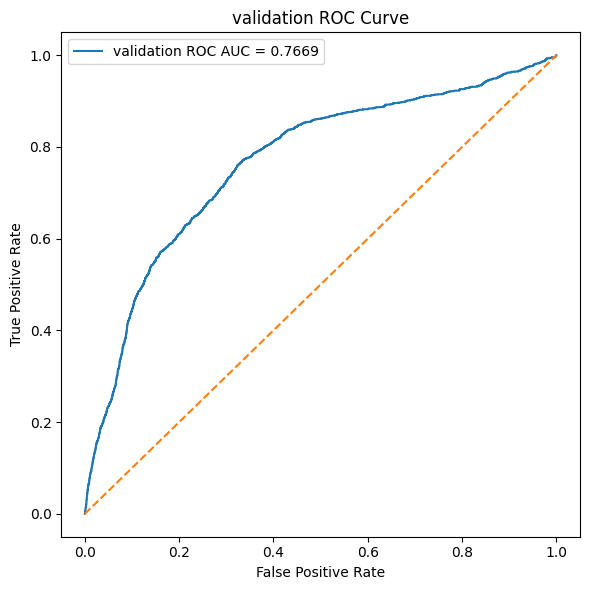

In [ ]:
param_grid = {
    "encoder_hidden_units": [[128]],
    "latent_dim": [128],
    "batch_size": [1024],
    "epochs": [20],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1e-3}],
    "cont_weight": [0.875, 0.9875, 1.],
    "num_noise": [0.025],
    "cat_noise": [0., 0.025, 0.05, 0.1],
}

results_table, model, best_config, best_auc = grid_search_autoencoder(
    param_grid=param_grid,
    X_train_cat=X_train_cat,
    X_train_cont=X_train_cont,
    X_val_cat=X_val_cat,
    X_val_cont=X_val_cont,
    y_val=y_val,
    num_embeddings=num_embeddings,
)

print(results_table[[
    "encoder_hidden_units", "latent_dim", "batch_size", "epochs",
    "optimizer_name", "optimizer_params", "cont_weight",
    "num_noise", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_val_cat, dtype=torch.long),
    torch.tensor(X_val_cont, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)
val_results = evaluate_scores(y_val_eval, val_scores, split_name="validation")

test threshold: -1.007841
test f1: 0.4298
test auc: 0.7639
test accuracy: 0.8201
Predicted      0     1
Actual                
0          10405  1652
1            837   938
              precision    recall  f1-score   support

           0     0.9255    0.8630    0.8932     12057
           1     0.3622    0.5285    0.4298      1775

    accuracy                         0.8201     13832
   macro avg     0.6439    0.6957    0.6615     13832
weighted avg     0.8533    0.8201    0.8337     13832



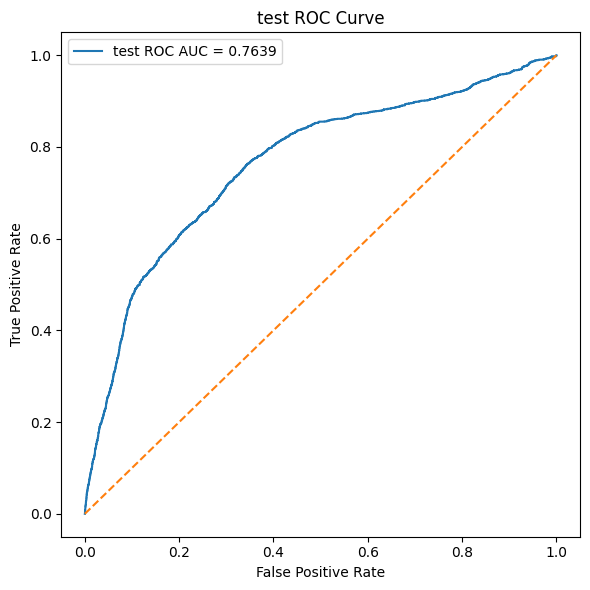

In [ ]:
test_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_test_cat, dtype=torch.long),
    torch.tensor(X_test_cont, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

test_dl = torch.utils.data.DataLoader(test_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

test_scores, y_test_eval = anomaly_scores(
    model,
    test_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)

test_results = evaluate_scores(
    y_test_eval,
    test_scores,
    threshold=val_results["threshold"],
    split_name="test"
)

<a name="e3"></a>

# Fraud Detection - Exercise: Silence Speaks Volumes

Missing data are not all the same.

A first case is **Missing At Random (MAR)**, where the event “a value is missing” is independent of the value itself. Informally, the missingness mechanism does not directly depend on the unseen value.

A second case is **Missing Not At Random (MNAR)**, where the probability that a value is missing depends on the value itself.

Without additional information, it is often safer to assume that missingness may carry information, that is, that we may be in a partially **MNAR** setting. In that case, simple **mean imputation** can be especially suboptimal, because it removes the distinction between “observed value” and “missing value replaced by an average”.

A possible fix is to explicitly reintroduce this information into the model.

---

You have to modify the preprocessing step so that, **before imputation**, you add one additional **categorical indicator column** for each continuous variable, signaling whether that value was missing.

In other words, for every continuous variable \(x_j\), create a new binary feature:

- `0` if the value is observed
- `1` if the value is missing

These new indicator variables should then be treated as **categorical variables** and can be concatened to the former ones.

------

If you do not have a **GPU** available, just run the best configuration we found:
```
Best config: {'encoder_hidden_units': [128], 'latent_dim': 128, 'batch_size': 1024, 'epochs': 20, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.001}, 'cont_weight': 0.9875, 'num_noise': 0.025, 'cat_noise': 0.1}
```



In [ ]:
# YOUR CODE HERE

**Solution**

In [ ]:
X_train_cont = np.load("X_train_cont.npy")
X_train_cat = np.load("X_train_cat.npy")
y_train = np.load("y_train.npy")

X_val_cont = np.load("X_val_cont.npy")
X_val_cat = np.load("X_val_cat.npy")
y_val = np.load("y_val.npy")

X_test_cont = np.load("X_test_cont.npy")
X_test_cat = np.load("X_test_cat.npy")
y_test = np.load("y_test.npy")


############ AUGMENTED MISSING DATA ##########################

X_train_cont_nan = np.isnan(X_train_cont).astype(np.int32)
X_val_cont_nan = np.isnan(X_val_cont).astype(np.int32)
X_test_cont_nan = np.isnan(X_test_cont).astype(np.int32)

imputer = SimpleImputer(strategy="mean")

X_train_cont = imputer.fit_transform(X_train_cont)

X_val_cont = imputer.transform(X_val_cont)
X_test_cont = imputer.transform(X_test_cont)

X_train_cat = np.concatenate([X_train_cat, X_train_cont_nan], axis=1).astype(np.int32)
X_val_cat = np.concatenate([X_val_cat, X_val_cont_nan], axis=1).astype(np.int32)
X_test_cat = np.concatenate([X_test_cat, X_test_cont_nan], axis=1).astype(np.int32)


########## CAT & NUM PREPROCESSING ##################



categorical_transformer = CategoricalTransformer()
quantile_transformer = QuantileTransformer(output_distribution="uniform")

X_train_cat = categorical_transformer.fit_transform(X_train_cat).astype(np.int64)

X_val_cat = categorical_transformer.transform(X_val_cat).astype(np.int64)
X_test_cat = categorical_transformer.transform(X_test_cat).astype(np.int64)

X_train_cont = 2 * quantile_transformer.fit_transform(X_train_cont).astype(np.float32) - 1

X_val_cont = 2 * quantile_transformer.transform(X_val_cont).astype(np.float32) - 1
X_test_cont = 2 * quantile_transformer.transform(X_test_cont).astype(np.float32) - 1

num_embeddings = []
for i in range(X_train_cat.shape[1]):
  x = X_train_cat[:, i]

  values = np.unique(x)
  vmax = values.shape[0]
  num_embeddings.append(vmax + 1)



Training with config: {'encoder_hidden_units': [128], 'latent_dim': 128, 'batch_size': 1024, 'epochs': 20, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.001}, 'cont_weight': 0.875, 'num_noise': 0.025, 'cat_noise': 0.0}
  Epoch 1/20 - loss: 1.0197 - cont_nll: 0.9586 - cat_ce: 1.4475
  Epoch 2/20 - loss: 0.2318 - cont_nll: 0.1687 - cat_ce: 0.6740
  Epoch 3/20 - loss: -0.5910 - cont_nll: -0.7469 - cat_ce: 0.5002
  Epoch 4/20 - loss: -0.8624 - cont_nll: -1.0537 - cat_ce: 0.4766
  Epoch 5/20 - loss: -0.9858 - cont_nll: -1.1924 - cat_ce: 0.4611
  Epoch 6/20 - loss: -1.0793 - cont_nll: -1.2977 - cat_ce: 0.4492
  Epoch 7/20 - loss: -1.1281 - cont_nll: -1.3521 - cat_ce: 0.4400
  Epoch 8/20 - loss: -1.2027 - cont_nll: -1.4363 - cat_ce: 0.4323
  Epoch 9/20 - loss: -1.2733 - cont_nll: -1.5161 - cat_ce: 0.4257
  Epoch 10/20 - loss: -1.2781 - cont_nll: -1.5209 - cat_ce: 0.4214
  Epoch 11/20 - loss: -1.2934 - cont_nll: -1.5379 - cat_ce: 0.4178
  Epoch 12/20 - loss: -1.3155 - cont_nll: -1.56

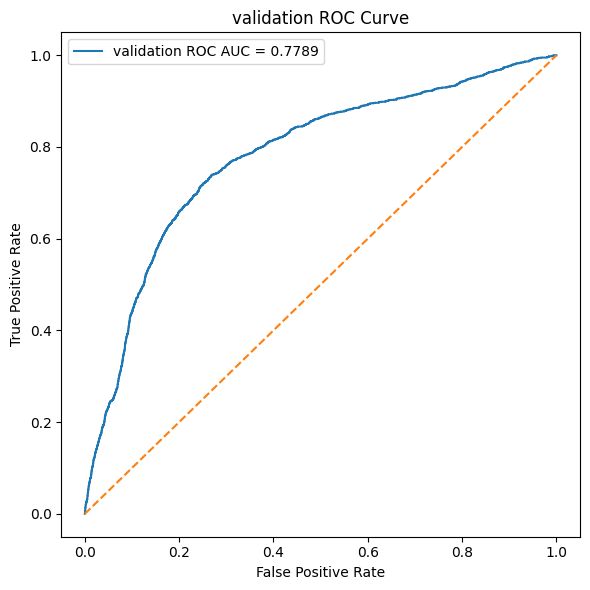

In [ ]:
param_grid = {
    "encoder_hidden_units": [[128]],
    "latent_dim": [128],
    "batch_size": [1024],
    "epochs": [20],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1e-3}],
    "cont_weight": [0.875, 0.9875, 1.],
    "num_noise": [0.025],
    "cat_noise": [0., 0.025, 0.05, 0.1],
}

results_table, model, best_config, best_auc = grid_search_autoencoder(
    param_grid=param_grid,
    X_train_cat=X_train_cat,
    X_train_cont=X_train_cont,
    X_val_cat=X_val_cat,
    X_val_cont=X_val_cont,
    y_val=y_val,
    num_embeddings=num_embeddings,
)

print(results_table[[
    "encoder_hidden_units", "latent_dim", "batch_size", "epochs",
    "optimizer_name", "optimizer_params", "cont_weight",
    "num_noise", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_val_cat, dtype=torch.long),
    torch.tensor(X_val_cont, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)
val_results = evaluate_scores(y_val_eval, val_scores, split_name="validation")

test threshold: -1.273877
test f1: 0.4414
test auc: 0.7798
test accuracy: 0.8066
Predicted      0     1
Actual                
0          10100  1957
1            718  1057
              precision    recall  f1-score   support

           0     0.9336    0.8377    0.8831     12057
           1     0.3507    0.5955    0.4414      1775

    accuracy                         0.8066     13832
   macro avg     0.6422    0.7166    0.6622     13832
weighted avg     0.8588    0.8066    0.8264     13832



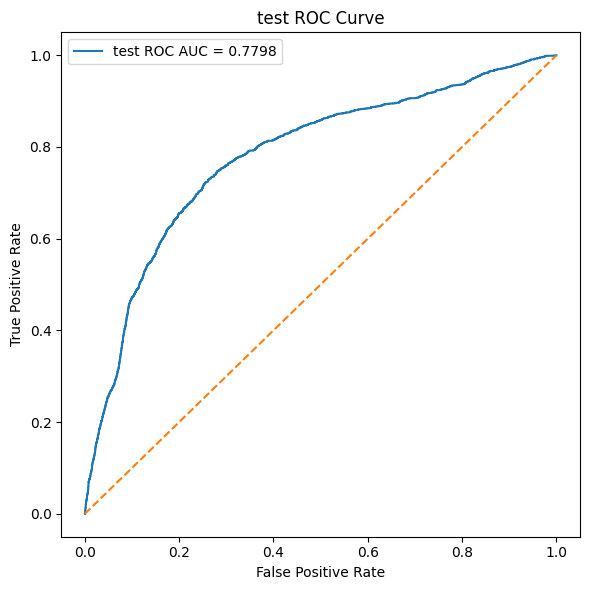

In [ ]:
test_ds = torch.utils.data.TensorDataset(
    torch.tensor(X_test_cat, dtype=torch.long),
    torch.tensor(X_test_cont, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

test_dl = torch.utils.data.DataLoader(test_ds, batch_size=best_config["batch_size"] * 2, shuffle=False)

test_scores, y_test_eval = anomaly_scores(
    model,
    test_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cont_weight=best_config["cont_weight"],
)

test_results = evaluate_scores(
    y_test_eval,
    test_scores,
    threshold=val_results["threshold"],
    split_name="test"
)

# INCART Data

Our data are derived from the **St Petersburg INCART 12-lead Arrhythmia Database**.

For this project, we preprocessed the raw INCART recordings into **beat-centered windows** of shape **(160, 12)**, where:
- **160** is the number of time samples in each window
- **12** is the number of ECG leads

We then built a binary anomaly-detection dataset:
- **0 = normal beat**
- **1 = anomalous beat**

Our final working splits are:

- **Training set**: **10,000** samples, all **normal**
- **Validation set**: **5,000** samples  
  - **2,500 normal**
  - **2,500 anomalous**
- **Small test set**: **half of the full test set**, with the **same anomaly proportion** as the original test set

In summary, this dataset is a **preprocessed beat-level subset of INCART**, designed for anomaly detection on multilead ECG signals.

In [ ]:
ZIP_PATH = Path("incart_small.zip")
EXTRACT_DIR = Path("incart_small_unzip")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

X_train = np.load(EXTRACT_DIR / "X_train.npy")
y_train = np.load(EXTRACT_DIR / "y_train.npy")
X_val = np.load(EXTRACT_DIR / "X_val.npy")
y_val = np.load(EXTRACT_DIR / "y_val.npy")
X_test = np.load(EXTRACT_DIR / "X_test_small.npy")
y_test = np.load(EXTRACT_DIR / "y_test_small.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (10000, 160, 12)
y_train: (10000,)
X_val: (5000, 160, 12)
y_val: (5000,)
X_test: (19150, 160, 12)
y_test: (19150,)


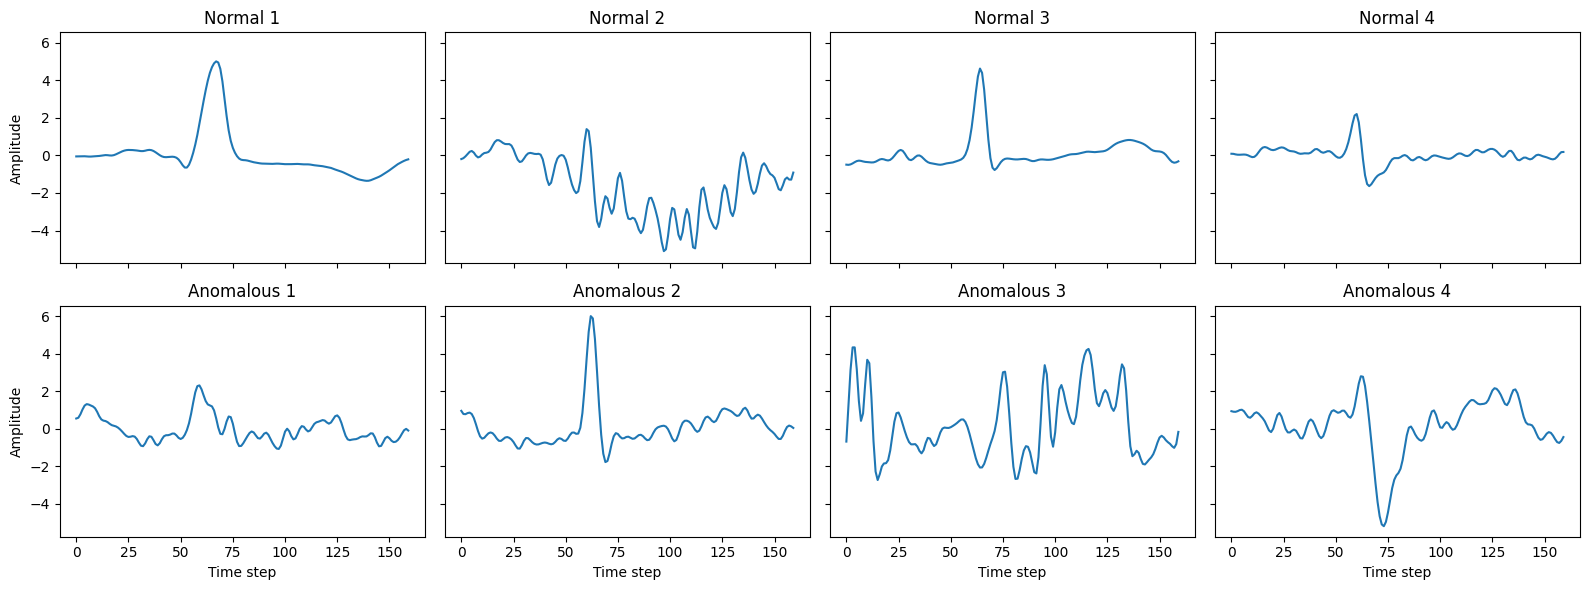

In [ ]:
normal_idx = np.where(y_val == 0)[0][:4]
anomaly_idx = np.where(y_val == 1)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)

for i, idx in enumerate(normal_idx):
    axes[0, i].plot(X_val[idx, :, 0])
    axes[0, i].set_title(f"Normal {i+1}")

for i, idx in enumerate(anomaly_idx):
    axes[1, i].plot(X_val[idx, :, 0])
    axes[1, i].set_title(f"Anomalous {i+1}")

axes[0, 0].set_ylabel("Amplitude")
axes[1, 0].set_ylabel("Amplitude")

for ax in axes[1, :]:
    ax.set_xlabel("Time step")

plt.tight_layout()
plt.show()

# INCART - Baseline: One-Class SVM

Best validation threshold: 1.2407112623861205
Best validation F1: 0.9221183800623053
Validation AUC: 0.9423545600000001
Test F1: 0.6968142226464622
Test AUC: 0.9700650383137477

Validation confusion matrix:
[[2405   95]
 [ 280 2220]]

Test confusion matrix:
[[13689  2475]
 [   66  2920]]

Test classification report:
              precision    recall  f1-score   support

           0     0.9952    0.8469    0.9151     16164
           1     0.5412    0.9779    0.6968      2986

    accuracy                         0.8673     19150
   macro avg     0.7682    0.9124    0.8059     19150
weighted avg     0.9244    0.8673    0.8810     19150



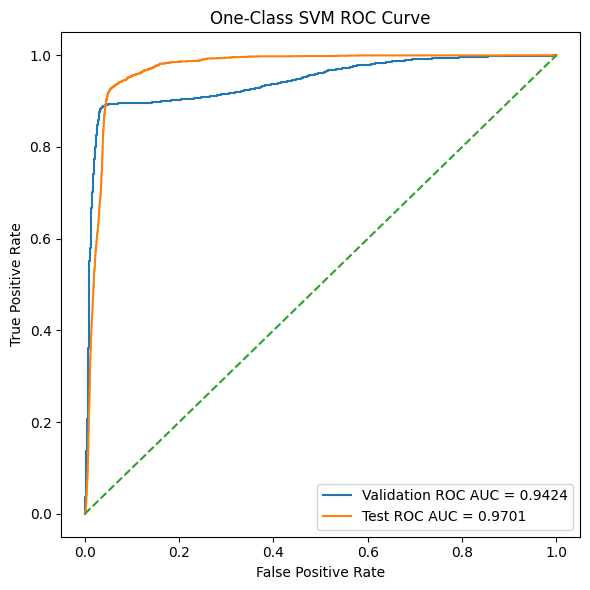

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_normal = X_train_flat[y_train == 0]

scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

pca = PCA(n_components=50, random_state=42)
X_train_normal_pca = pca.fit_transform(X_train_normal_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

ocsvm.fit(X_train_normal_pca)

val_scores = -ocsvm.decision_function(X_val_pca)
test_scores = -ocsvm.decision_function(X_test_pca)

val_auc = roc_auc_score(y_val, val_scores)
test_auc = roc_auc_score(y_test, test_scores)

thresholds = np.unique(np.quantile(val_scores, np.linspace(0.01, 0.99, 200)))

best_f1 = -1
best_threshold = None

for thr in thresholds:
    y_val_pred = (val_scores >= thr).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr

y_val_pred = (val_scores >= best_threshold).astype(int)
y_test_pred = (test_scores >= best_threshold).astype(int)

test_f1 = f1_score(y_test, y_test_pred)

print("Best validation threshold:", best_threshold)
print("Best validation F1:", best_f1)
print("Validation AUC:", val_auc)
print("Test F1:", test_f1)
print("Test AUC:", test_auc)

print("\nValidation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nTest confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nTest classification report:")
print(classification_report(y_test, y_test_pred, digits=4))

fpr_val, tpr_val, _ = roc_curve(y_val, val_scores)
fpr_test, tpr_test, _ = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr_val, tpr_val, label=f"Validation ROC AUC = {val_auc:.4f}")
plt.plot(fpr_test, tpr_test, label=f"Test ROC AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-Class SVM ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# INCART - Baseline: Isolation Forest

X_train_flat: (10000, 1920)
X_val_flat  : (5000, 1920)
X_test_flat : (19150, 1920)
X_train_normal: (10000, 1920)
Best validation threshold: -0.03135647866094224
Best validation F1: 0.8976116303219107
Validation AUC: 0.9321073599999998
Test F1: 0.7264506405425772
Test AUC: 0.969168252471776

Validation confusion matrix:
[[2346  154]
 [ 339 2161]]

Test confusion matrix:
[[14080  2084]
 [   94  2892]]

Test classification report:
              precision    recall  f1-score   support

           0     0.9934    0.8711    0.9282     16164
           1     0.5812    0.9685    0.7265      2986

    accuracy                         0.8863     19150
   macro avg     0.7873    0.9198    0.8273     19150
weighted avg     0.9291    0.8863    0.8967     19150



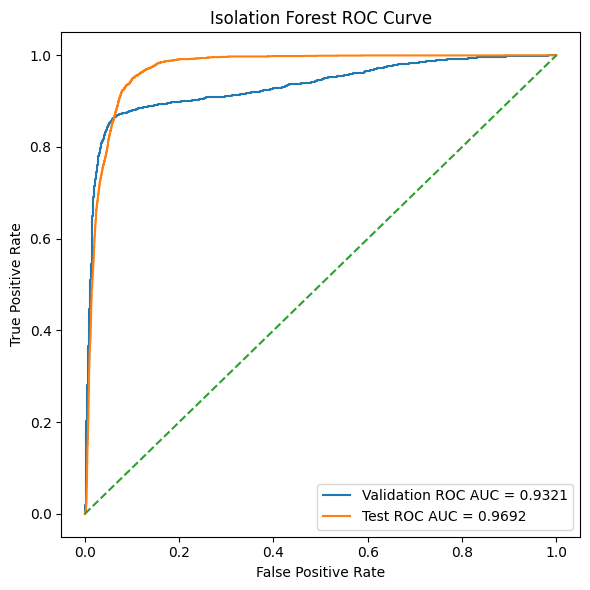

In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_normal = X_train_flat[y_train == 0]

print("X_train_flat:", X_train_flat.shape)
print("X_val_flat  :", X_val_flat.shape)
print("X_test_flat :", X_test_flat.shape)
print("X_train_normal:", X_train_normal.shape)

iso = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_normal)

val_scores = -iso.decision_function(X_val_flat)
test_scores = -iso.decision_function(X_test_flat)

val_auc = roc_auc_score(y_val, val_scores)
test_auc = roc_auc_score(y_test, test_scores)

thresholds = np.unique(np.quantile(val_scores, np.linspace(0.01, 0.99, 200)))

best_f1 = -1
best_threshold = None

for thr in thresholds:
    y_val_pred = (val_scores >= thr).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr

y_val_pred = (val_scores >= best_threshold).astype(int)
y_test_pred = (test_scores >= best_threshold).astype(int)

test_f1 = f1_score(y_test, y_test_pred)

print("Best validation threshold:", best_threshold)
print("Best validation F1:", best_f1)
print("Validation AUC:", val_auc)
print("Test F1:", test_f1)
print("Test AUC:", test_auc)

print("\nValidation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nTest confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nTest classification report:")
print(classification_report(y_test, y_test_pred, digits=4))

fpr_val, tpr_val, _ = roc_curve(y_val, val_scores)
fpr_test, tpr_test, _ = roc_curve(y_test, test_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr_val, tpr_val, label=f"Validation ROC AUC = {val_auc:.4f}")
plt.plot(fpr_test, tpr_test, label=f"Test ROC AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Isolation Forest ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# INCART - LSTM

In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_dim, latent_dim):
        super().__init__()
        self.encoder_lstm1 = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.encoder_lstm2 = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=latent_dim,
            batch_first=True
        )
        self.decoder_lstm1 = nn.LSTM(
            input_size=latent_dim,
            hidden_size=latent_dim,
            batch_first=True
        )
        self.decoder_lstm2 = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        seq_len = x.size(1)
        x, _ = self.encoder_lstm1(x)
        _, (h_n, _) = self.encoder_lstm2(x)
        z = h_n[-1]
        z = z.unsqueeze(1).repeat(1, seq_len, 1)
        x, _ = self.decoder_lstm1(z)
        x, _ = self.decoder_lstm2(x)
        x = self.output_layer(x)
        return x


class LSTMVAE(nn.Module):
    def __init__(self, n_features, hidden_dim, latent_dim):
        super().__init__()

        self.encoder_lstm1 = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.encoder_lstm2 = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, latent_dim)

        self.decoder_lstm1 = nn.LSTM(
            input_size=latent_dim,
            hidden_size=latent_dim,
            batch_first=True
        )
        self.decoder_lstm2 = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, n_features)

    def encode(self, x):
        x, _ = self.encoder_lstm1(x)
        _, (h_n, _) = self.encoder_lstm2(x)
        h = h_n[-1]
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, seq_len):
        z = self.decoder_input(z)
        z = z.unsqueeze(1).repeat(1, seq_len, 1)
        x, _ = self.decoder_lstm1(z)
        x, _ = self.decoder_lstm2(x)
        x = self.output_layer(x)
        return x

    def forward(self, x):
        seq_len = x.size(1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, seq_len)
        return recon, mu, logvar


def get_optimizer(model, optimizer_name="adam", optimizer_params=None):
    if optimizer_params is None:
        optimizer_params = {"lr": 1e-3}

    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(model.parameters(), **optimizer_params)
    elif optimizer_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), **optimizer_params)
    elif optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), **optimizer_params)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), **optimizer_params)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    return optimizer


def reconstruction_mse_per_sample(x, recon):
    return torch.mean((x - recon) ** 2, dim=(1, 2))


def vae_loss_per_sample(x, recon, mu, logvar, beta):
    recon_loss = reconstruction_mse_per_sample(x, recon)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss


def get_beta_value(epoch, beta_config):
    schedule = beta_config.get("schedule", "constant")

    if schedule == "constant":
        return beta_config.get("beta", 0.01)

    if schedule == "linear_warmup":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        warmup_epochs = beta_config.get("warmup_epochs", 10)
        if warmup_epochs <= 1:
            return end
        alpha = min(epoch / (warmup_epochs - 1), 1.0)
        return start + alpha * (end - start)

    if schedule == "cyclical_linear":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        cycle_length = beta_config.get("cycle_length", 10)
        pos = epoch % cycle_length
        alpha = pos / max(cycle_length - 1, 1)
        return start + alpha * (end - start)

    if schedule == "sigmoid_warmup":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        midpoint = beta_config.get("midpoint", 10)
        steepness = beta_config.get("steepness", 1.0)
        x = (epoch - midpoint) / max(steepness, 1e-8)
        s = 1.0 / (1.0 + np.exp(-x))
        return start + (end - start) * s

    if schedule == "custom":
        fn = beta_config["fn"]
        return fn(epoch)

    raise ValueError(f"Unknown beta schedule: {schedule}")


def anomaly_scores(model, dataloader, device, model_type="ae", beta_for_score=0.0):
    model.eval()
    scores = []
    ys = []

    with torch.no_grad():
        for batch in dataloader:
            xb = batch[0].to(device)

            if model_type == "ae":
                recon = model(xb)
                score = reconstruction_mse_per_sample(xb, recon)
            elif model_type == "vae":
                recon, mu, logvar = model(xb)
                score, _, _ = vae_loss_per_sample(xb, recon, mu, logvar, beta=beta_for_score)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")

            scores.append(score.cpu().numpy())

            if len(batch) == 2:
                ys.append(batch[1].cpu().numpy())

    scores = np.concatenate(scores)
    ys = np.concatenate(ys) if ys else None
    return scores, ys


def evaluate_scores(y_true, scores, threshold=None, split_name="validation"):
    auc = roc_auc_score(y_true, scores)

    if threshold is None:
        thresholds = np.unique(np.quantile(scores, np.linspace(0.01, 0.99, 300)))
        best_f1 = -1
        best_threshold = None
        best_pred = None

        for thr in thresholds:
            pred = (scores >= thr).astype(int)
            f1 = f1_score(y_true, pred)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = thr
                best_pred = pred
    else:
        best_threshold = threshold
        best_pred = (scores >= best_threshold).astype(int)
        best_f1 = f1_score(y_true, best_pred)

    acc = accuracy_score(y_true, best_pred)
    crosstab = pd.crosstab(
        pd.Series(y_true, name="Actual"),
        pd.Series(best_pred, name="Predicted")
    )

    print(f"{split_name} threshold: {best_threshold:.6f}")
    print(f"{split_name} f1: {best_f1:.4f}")
    print(f"{split_name} auc: {auc:.4f}")
    print(f"{split_name} accuracy: {acc:.4f}")
    print(crosstab)
    print(classification_report(y_true, best_pred, digits=4))

    fpr, tpr, _ = roc_curve(y_true, scores)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"{split_name} ROC AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name} ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "threshold": best_threshold,
        "f1": best_f1,
        "auc": auc,
        "accuracy": acc,
        "crosstab": crosstab
    }


def build_dataloaders(X_train, X_val, y_val, batch_size):
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32)
    )

    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size * 2, shuffle=False)
    return train_dl, val_dl


def train_one_config(
    train_dl,
    val_dl,
    n_features,
    hidden_dim,
    latent_dim,
    optimizer_name,
    optimizer_params,
    epochs,
    device,
    model_type="ae",
    beta_config=None,
    beta_score_eval=None,
):
    if beta_config is None:
        beta_config = {"schedule": "constant", "beta": 0.01}

    if model_type == "ae":
        model = LSTMAutoencoder(
            n_features=n_features,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
        ).to(device)
    elif model_type == "vae":
        model = LSTMVAE(
            n_features=n_features,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
        ).to(device)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    optimizer = get_optimizer(model, optimizer_name, optimizer_params)

    history = {
        "total": [],
        "recon": [],
        "kl": [],
        "beta": [],
    }

    for epoch in range(epochs):
        model.train()
        epoch_total_losses = []
        epoch_recon_losses = []
        epoch_kl_losses = []

        beta = get_beta_value(epoch, beta_config)
        history["beta"].append(beta)

        for (xb,) in train_dl:
            xb = xb.to(device)

            optimizer.zero_grad()

            if model_type == "ae":
                recon = model(xb)
                loss_per_sample = reconstruction_mse_per_sample(xb, recon)
                recon_loss = loss_per_sample.mean()
                kl_loss = torch.tensor(0.0, device=device)
                total_loss = recon_loss
            else:
                recon, mu, logvar = model(xb)
                total_per_sample, recon_per_sample, kl_per_sample = vae_loss_per_sample(
                    xb, recon, mu, logvar, beta=beta
                )
                total_loss = total_per_sample.mean()
                recon_loss = recon_per_sample.mean()
                kl_loss = kl_per_sample.mean()

            total_loss.backward()
            optimizer.step()

            epoch_total_losses.append(total_loss.item())
            epoch_recon_losses.append(recon_loss.item())
            epoch_kl_losses.append(kl_loss.item())

        history["total"].append(np.mean(epoch_total_losses))
        history["recon"].append(np.mean(epoch_recon_losses))
        history["kl"].append(np.mean(epoch_kl_losses))

        if model_type == "ae":
            print(
                f"  Epoch {epoch + 1}/{epochs} - "
                f"loss: {history['total'][-1]:.4f}"
            )
        else:
            print(
                f"  Epoch {epoch + 1}/{epochs} - "
                f"loss: {history['total'][-1]:.4f} - "
                f"recon: {history['recon'][-1]:.4f} - "
                f"kl: {history['kl'][-1]:.4f} - "
                f"beta: {beta:.5f}"
            )

    if beta_score_eval is None:
        beta_score_eval = 0.0 if model_type == "ae" else get_beta_value(epochs - 1, beta_config)

    val_scores, y_val_eval = anomaly_scores(
        model,
        val_dl,
        device,
        model_type=model_type,
        beta_for_score=beta_score_eval,
    )
    val_auc = roc_auc_score(y_val_eval, val_scores)

    return model, val_auc, history


def grid_search_autoencoder(param_grid, X_train, X_val, y_val):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]

    all_results = []
    best_auc = -1
    best_model_state = None
    best_config = None
    best_history = None

    for combo in itertools.product(*values):
        config = dict(zip(keys, combo))

        print(f"\nTraining with config: {config}")

        train_dl, val_dl = build_dataloaders(
            X_train, X_val, y_val, config["batch_size"]
        )

        model, val_auc, history = train_one_config(
            train_dl=train_dl,
            val_dl=val_dl,
            n_features=X_train.shape[2],
            hidden_dim=config["hidden_dim"],
            latent_dim=config["latent_dim"],
            optimizer_name=config["optimizer_name"],
            optimizer_params=config["optimizer_params"],
            epochs=config["epochs"],
            device=device,
            model_type=config.get("model_type", "ae"),
            beta_config=config.get("beta_config", {"schedule": "constant", "beta": 0.01}),
            beta_score_eval=config.get("beta_score_eval", None),
        )

        row = config.copy()
        row["val_auc"] = val_auc
        all_results.append(row)

        if val_auc > best_auc:
            best_auc = val_auc
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_config = config.copy()
            best_history = history.copy()

    results_table = pd.DataFrame(all_results).sort_values("val_auc", ascending=False).reset_index(drop=True)

    if best_config.get("model_type", "ae") == "ae":
        best_model = LSTMAutoencoder(
            n_features=X_train.shape[2],
            hidden_dim=best_config["hidden_dim"],
            latent_dim=best_config["latent_dim"],
        ).to(device)
    else:
        best_model = LSTMVAE(
            n_features=X_train.shape[2],
            hidden_dim=best_config["hidden_dim"],
            latent_dim=best_config["latent_dim"],
        ).to(device)

    best_model.load_state_dict(best_model_state)

    return results_table, best_model, best_config, best_auc, best_history


def anomaly_scores_vae_repeated(model, dataloader, device, n_samples=10, score_mode="recon"):
    model.eval()
    scores = []
    ys = []

    with torch.no_grad():
        for batch in dataloader:
            xb = batch[0].to(device)

            mu, logvar = model.encode(xb)
            seq_len = xb.size(1)

            sample_scores = []

            for _ in range(n_samples):
                z = model.reparameterize(mu, logvar)
                recon = model.decode(z, seq_len)

                if score_mode == "recon":
                    score = reconstruction_mse_per_sample(xb, recon)
                elif score_mode == "recon_plus_kl":
                    _, recon_loss, kl_loss = vae_loss_per_sample(xb, recon, mu, logvar, beta=1.0)
                    score = recon_loss + kl_loss
                else:
                    raise ValueError(f"Unknown score_mode: {score_mode}")

                sample_scores.append(score.unsqueeze(0))

            sample_scores = torch.cat(sample_scores, dim=0)
            score = sample_scores.mean(dim=0)

            scores.append(score.cpu().numpy())

            if len(batch) == 2:
                ys.append(batch[1].cpu().numpy())

    scores = np.concatenate(scores)
    ys = np.concatenate(ys) if ys else None
    return scores, ys

In [ ]:
X_train = np.load(EXTRACT_DIR / "X_train.npy")
y_train = np.load(EXTRACT_DIR / "y_train.npy")
X_val = np.load(EXTRACT_DIR / "X_val.npy")
y_val = np.load(EXTRACT_DIR / "y_val.npy")
X_test = np.load(EXTRACT_DIR / "X_test_small.npy")
y_test = np.load(EXTRACT_DIR / "y_test_small.npy")

######### DATA ARE ALREADY STANDARDIZED PER CHANNEL  ##################

channel_mean = X_train.mean(axis=(0, 1))
channel_std = X_train.std(axis=(0, 1))

print("channel_mean shape:", channel_mean)
print("channel_std shape :", channel_std)

channel_mean shape: [ 0.05394863  0.03618414  0.02140165 -0.04311271  0.00059217  0.03018195
 -0.02249421  0.01929763  0.0334203   0.03643885  0.03577257  0.03871462]
channel_std shape : [1.064403   0.98650694 0.96302956 1.0163941  0.9527263  0.9729434
 1.0364227  1.028179   1.0379146  1.019455   1.0254166  1.0208247 ]



Training with config: {'model_type': 'ae', 'hidden_dim': 64, 'latent_dim': 32, 'batch_size': 128, 'epochs': 15, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.0001}}
  Epoch 1/15 - loss: 1.0287
  Epoch 2/15 - loss: 1.0243
  Epoch 3/15 - loss: 1.0214
  Epoch 4/15 - loss: 1.0179
  Epoch 5/15 - loss: 1.0150
  Epoch 6/15 - loss: 1.0053
  Epoch 7/15 - loss: 0.9944
  Epoch 8/15 - loss: 0.9863
  Epoch 9/15 - loss: 0.9394
  Epoch 10/15 - loss: 0.8753
  Epoch 11/15 - loss: 0.8221
  Epoch 12/15 - loss: 0.7922
  Epoch 13/15 - loss: 0.7655
  Epoch 14/15 - loss: 0.7434
  Epoch 15/15 - loss: 0.7328

Training with config: {'model_type': 'ae', 'hidden_dim': 64, 'latent_dim': 32, 'batch_size': 128, 'epochs': 15, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.0002}}
  Epoch 1/15 - loss: 1.0251
  Epoch 2/15 - loss: 1.0201
  Epoch 3/15 - loss: 1.0165
  Epoch 4/15 - loss: 1.0135
  Epoch 5/15 - loss: 0.9945
  Epoch 6/15 - loss: 0.9688
  Epoch 7/15 - loss: 0.8847
  Epoch 8/15 - loss: 0.8007


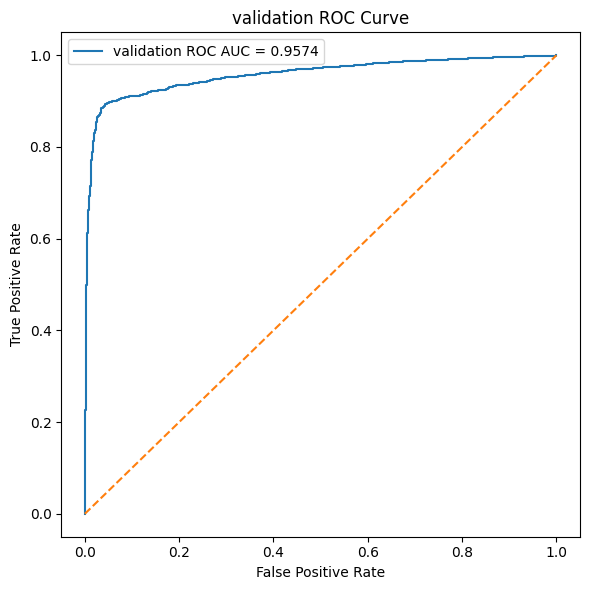

In [ ]:
param_grid = {
    "model_type": ["ae"],
    "hidden_dim": [64],
    "latent_dim": [32],
    "batch_size": [128],
    "epochs": [15],
    "optimizer_name": ["adam", "rmsprop"],
    "optimizer_params": [{"lr": 1e-4 * (2**k)} for k in range(5)],
}

results_table, model, best_config, best_auc, best_history = grid_search_autoencoder(
    param_grid=param_grid,
    X_train=X_train,
    X_val=X_val,
    y_val=y_val,
)

print(results_table[[
    "model_type", "hidden_dim", "latent_dim", "batch_size",
    "epochs", "optimizer_name", "optimizer_params", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    ),
    batch_size=best_config["batch_size"] * 2,
    shuffle=False
)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    model_type="ae",
)

val_results = evaluate_scores(
    y_val_eval,
    val_scores,
    split_name="validation"
)

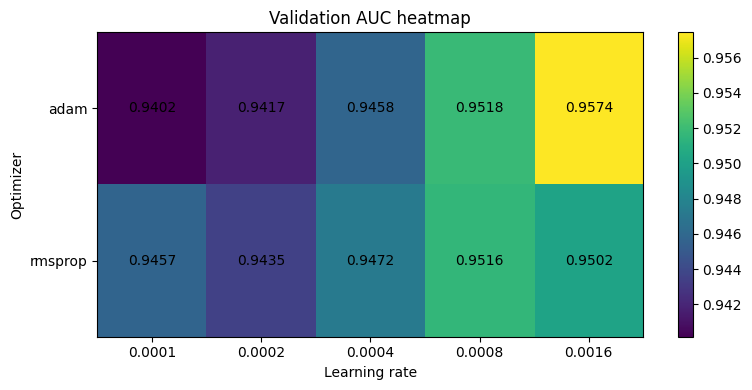

In [ ]:
heatmap_df = results_table.copy()
heatmap_df["lr"] = heatmap_df["optimizer_params"].apply(lambda d: d["lr"])

pivot_df = heatmap_df.pivot_table(
    index="optimizer_name",
    columns="lr",
    values="val_auc",
    aggfunc="mean"
)

pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot_df.values, aspect="auto")

ax.set_xticks(range(len(pivot_df.columns)))
ax.set_xticklabels([f"{x:.4g}" for x in pivot_df.columns])
ax.set_yticks(range(len(pivot_df.index)))
ax.set_yticklabels(pivot_df.index)

for i in range(pivot_df.shape[0]):
    for j in range(pivot_df.shape[1]):
        ax.text(j, i, f"{pivot_df.iloc[i, j]:.4f}", ha="center", va="center")

ax.set_xlabel("Learning rate")
ax.set_ylabel("Optimizer")
ax.set_title("Validation AUC heatmap")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


Training with config: {'model_type': 'ae', 'hidden_dim': 128, 'latent_dim': 8, 'batch_size': 128, 'epochs': 15, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.0015}}
  Epoch 1/15 - loss: 1.0215
  Epoch 2/15 - loss: 1.0186
  Epoch 3/15 - loss: 1.0187
  Epoch 4/15 - loss: 1.0228
  Epoch 5/15 - loss: 1.0239
  Epoch 6/15 - loss: 1.0243
  Epoch 7/15 - loss: 1.0213
  Epoch 8/15 - loss: 1.0202
  Epoch 9/15 - loss: 1.0217
  Epoch 10/15 - loss: 1.0197
  Epoch 11/15 - loss: 1.0201
  Epoch 12/15 - loss: 1.0194
  Epoch 13/15 - loss: 1.0158
  Epoch 14/15 - loss: 1.0174
  Epoch 15/15 - loss: 1.0144

Training with config: {'model_type': 'ae', 'hidden_dim': 128, 'latent_dim': 16, 'batch_size': 128, 'epochs': 15, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.0015}}
  Epoch 1/15 - loss: 1.0219
  Epoch 2/15 - loss: 1.0142
  Epoch 3/15 - loss: 1.0128
  Epoch 4/15 - loss: 1.0197
  Epoch 5/15 - loss: 1.0198
  Epoch 6/15 - loss: 1.0186
  Epoch 7/15 - loss: 1.0181
  Epoch 8/15 - loss: 1.0074

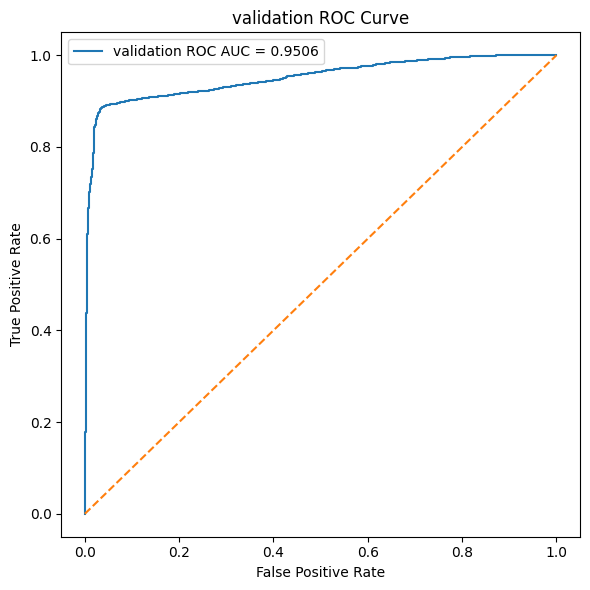

In [ ]:
param_grid = {
    "model_type": ["ae"],
    "hidden_dim": [128],
    "latent_dim": [8, 16, 32, 64],
    "batch_size": [128],
    "epochs": [15],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1.5e-3}],
}

results_table, model, best_config, best_auc, best_history = grid_search_autoencoder(
    param_grid=param_grid,
    X_train=X_train,
    X_val=X_val,
    y_val=y_val,
)

print(results_table[[
    "model_type", "hidden_dim", "latent_dim", "batch_size",
    "epochs", "optimizer_name", "optimizer_params", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    ),
    batch_size=best_config["batch_size"] * 2,
    shuffle=False
)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    model_type="ae",
)

val_results = evaluate_scores(
    y_val_eval,
    val_scores,
    split_name="validation"
)

test threshold: 0.905126
test f1: 0.7648
test auc: 0.9767
test accuracy: 0.9066
Predicted      0     1
Actual                
0          14452  1712
1             77  2909
              precision    recall  f1-score   support

           0     0.9947    0.8941    0.9417     16164
           1     0.6295    0.9742    0.7648      2986

    accuracy                         0.9066     19150
   macro avg     0.8121    0.9341    0.8533     19150
weighted avg     0.9378    0.9066    0.9141     19150



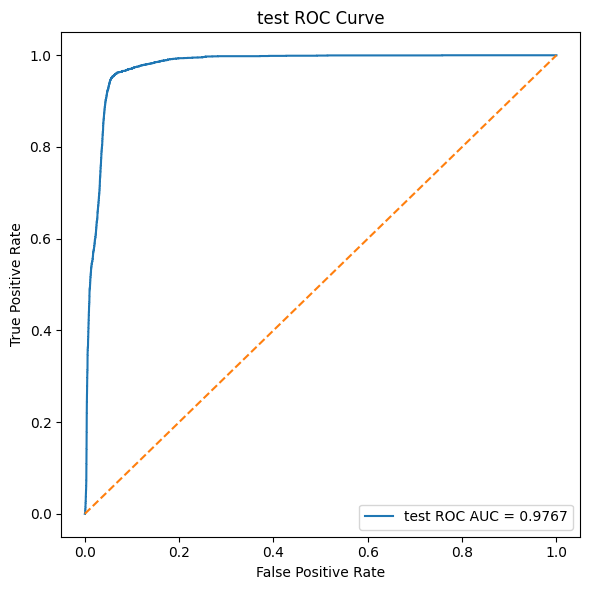

In [ ]:
test_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    ),
    batch_size=best_config["batch_size"] * 2,
    shuffle=False
)

test_scores, y_test_eval = anomaly_scores(
    model,
    test_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    model_type="ae",
)

test_results = evaluate_scores(
    y_test_eval,
    test_scores,
    threshold=val_results["threshold"],
    split_name="test"
)

# INCART - LSTM-VAE


Training with config: {'model_type': 'vae', 'hidden_dim': 64, 'latent_dim': 32, 'batch_size': 128, 'epochs': 15, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.0015}, 'beta_config': {'schedule': 'constant', 'beta': 0.0}}
  Epoch 1/15 - loss: 1.0207 - recon: 1.0207 - kl: 0.1595 - beta: 0.00000
  Epoch 2/15 - loss: 1.0159 - recon: 1.0159 - kl: 0.7065 - beta: 0.00000
  Epoch 3/15 - loss: 0.9920 - recon: 0.9920 - kl: 2.1009 - beta: 0.00000
  Epoch 4/15 - loss: 0.9271 - recon: 0.9271 - kl: 3.8889 - beta: 0.00000
  Epoch 5/15 - loss: 0.9399 - recon: 0.9399 - kl: 4.4466 - beta: 0.00000
  Epoch 6/15 - loss: 0.8635 - recon: 0.8635 - kl: 4.6271 - beta: 0.00000
  Epoch 7/15 - loss: 0.7730 - recon: 0.7730 - kl: 4.8863 - beta: 0.00000
  Epoch 8/15 - loss: 0.7386 - recon: 0.7386 - kl: 5.1163 - beta: 0.00000
  Epoch 9/15 - loss: 0.7227 - recon: 0.7227 - kl: 5.2575 - beta: 0.00000
  Epoch 10/15 - loss: 0.7136 - recon: 0.7136 - kl: 5.3787 - beta: 0.00000
  Epoch 11/15 - loss: 0.7020 - recon: 0

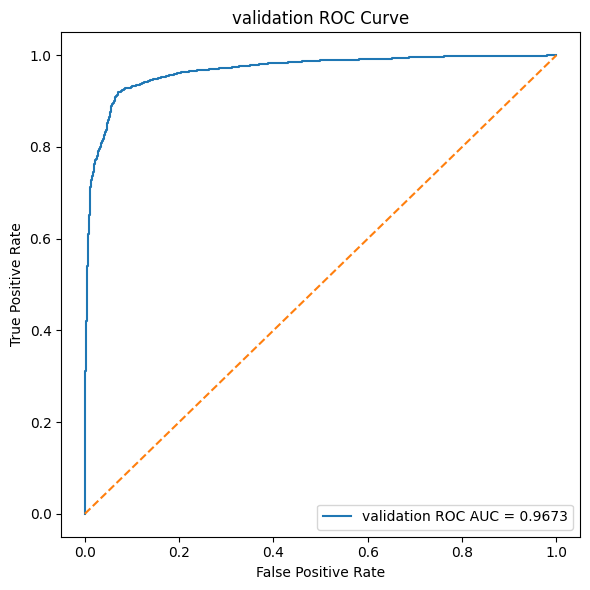

In [ ]:
param_grid = {
    "model_type": ["vae"],
    "hidden_dim": [64],
    "latent_dim": [32, 64, 128],
    "batch_size": [128],
    "epochs": [15],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1.5e-3}],
    "beta_config": [
        {"schedule": "constant", "beta": 0.0},
        {"schedule": "constant", "beta": 1e-4},
        {"schedule": "constant", "beta": 5e-4},
        {"schedule": "constant", "beta": 1e-3},
        {"schedule": "constant", "beta": 5e-3},
        {"schedule": "constant", "beta": 1e-2},
        {"schedule": "constant", "beta": 5e-2},
        {"schedule": "constant", "beta": 1e-1},
    ],
}



results_table, model, best_config, best_auc, best_history = grid_search_autoencoder(
    param_grid=param_grid,
    X_train=X_train,
    X_val=X_val,
    y_val=y_val,
)

print(results_table[[
    "model_type", "hidden_dim", "latent_dim", "batch_size",
    "epochs", "optimizer_name", "optimizer_params", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    ),
    batch_size=best_config["batch_size"] * 2,
    shuffle=False
)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    model_type=best_config["model_type"],
)

val_results = evaluate_scores(
    y_val_eval,
    val_scores,
    split_name="validation"
)

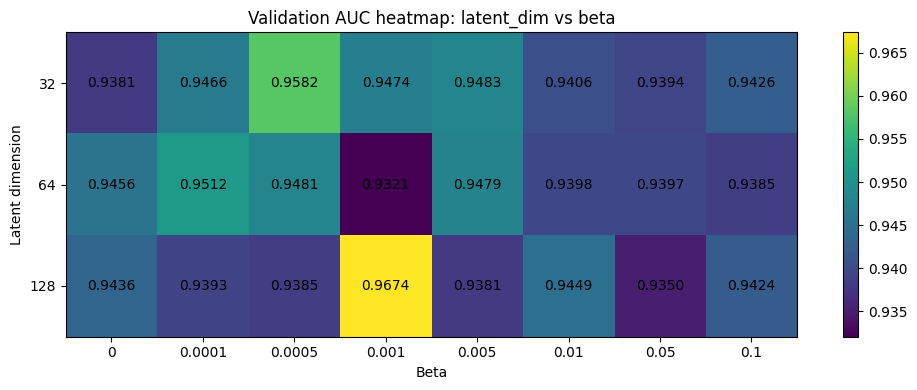

In [ ]:
heatmap_df = results_table.copy()
heatmap_df["beta"] = heatmap_df["beta_config"].apply(lambda d: d["beta"])

pivot_df = heatmap_df.pivot_table(
    index="latent_dim",
    columns="beta",
    values="val_auc",
    aggfunc="mean"
)

pivot_df = pivot_df.reindex(sorted(pivot_df.index), axis=0)
pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_df.values, aspect="auto")

ax.set_xticks(range(len(pivot_df.columns)))
ax.set_xticklabels([f"{x:.4g}" for x in pivot_df.columns])
ax.set_yticks(range(len(pivot_df.index)))
ax.set_yticklabels(pivot_df.index)

for i in range(pivot_df.shape[0]):
    for j in range(pivot_df.shape[1]):
        ax.text(j, i, f"{pivot_df.iloc[i, j]:.4f}", ha="center", va="center")

ax.set_xlabel("Beta")
ax.set_ylabel("Latent dimension")
ax.set_title("Validation AUC heatmap: latent_dim vs beta")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
n_samples_grid = [1, 3, 5, 10, 20, 30]


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    ),
    batch_size=best_config["batch_size"] * 2,
    shuffle=False
)

score_mode = "recon"

repeated_results = []

for n_samples in n_samples_grid:
    val_scores, y_val_eval = anomaly_scores_vae_repeated(
        model,
        val_dl,
        device,
        n_samples=n_samples,
        score_mode=score_mode
    )

    val_auc = roc_auc_score(y_val_eval, val_scores)

    repeated_results.append({
        "n_samples": n_samples,
        "val_auc": val_auc
    })

repeated_results = sorted(repeated_results, key=lambda x: x["val_auc"], reverse=True)
best_repeated = repeated_results[0]

print("Repeated-sampling validation results:")
for row in repeated_results:
    print(row)

print("\nBest repeated-sampling config based on AUC:")
print(best_repeated)

Repeated-sampling validation results:
{'n_samples': 1, 'val_auc': np.float64(0.9674171199999999)}
{'n_samples': 30, 'val_auc': np.float64(0.96739216)}
{'n_samples': 10, 'val_auc': np.float64(0.9673876800000001)}
{'n_samples': 5, 'val_auc': np.float64(0.96737504)}
{'n_samples': 3, 'val_auc': np.float64(0.96732448)}
{'n_samples': 20, 'val_auc': np.float64(0.9673131199999999)}

Best repeated-sampling config based on AUC:
{'n_samples': 1, 'val_auc': np.float64(0.9674171199999999)}


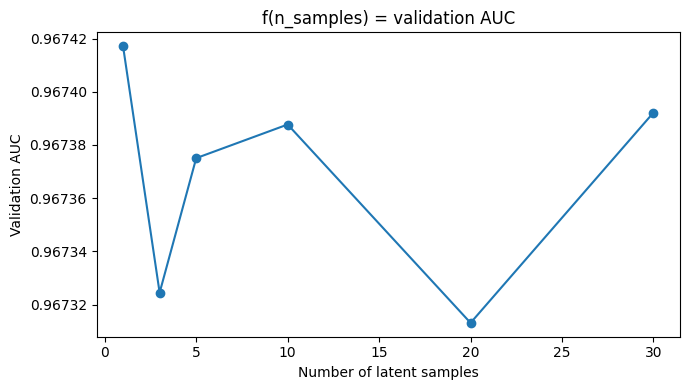

In [ ]:
xs = [r["n_samples"] for r in sorted(repeated_results, key=lambda x: x["n_samples"])]
ys = [r["val_auc"] for r in sorted(repeated_results, key=lambda x: x["n_samples"])]

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, marker="o")
plt.xlabel("Number of latent samples")
plt.ylabel("Validation AUC")
plt.title("f(n_samples) = validation AUC")
plt.tight_layout()
plt.show()

test threshold: 0.558673
test f1: 0.6422
test auc: 0.9733
test accuracy: 0.8287
Predicted      0     1
Actual                
0          12926  3238
1             42  2944
              precision    recall  f1-score   support

           0     0.9968    0.7997    0.8874     16164
           1     0.4762    0.9859    0.6422      2986

    accuracy                         0.8287     19150
   macro avg     0.7365    0.8928    0.7648     19150
weighted avg     0.9156    0.8287    0.8492     19150



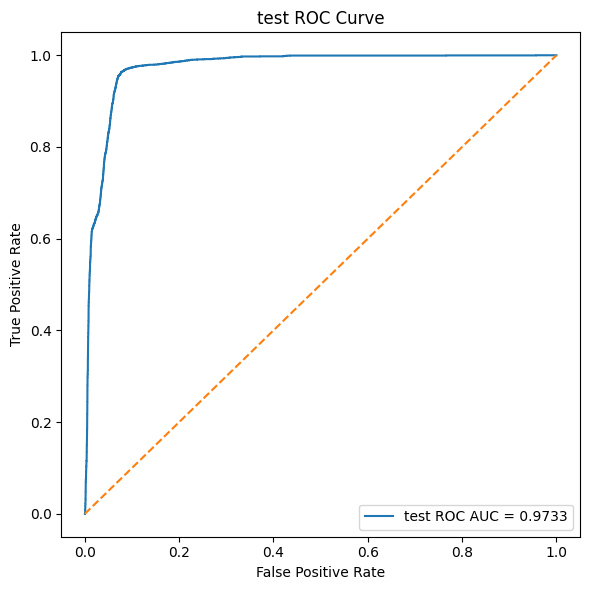

In [ ]:
test_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    ),
    batch_size=best_config["batch_size"] * 2,
    shuffle=False
)

test_scores, y_test_eval = anomaly_scores(
    model,
    test_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    model_type=best_config["model_type"],
)

test_results = evaluate_scores(
    y_test_eval,
    test_scores,
    threshold=val_results["threshold"],
    split_name="test"
)

<a name="e4"></a>

# INCART – Exercise: The Importance of Beta Earnest

In this exercise, we study the role of **beta** in the loss of a **Variational Autoencoder (VAE)** and investigate why **warm-up schedules** can be useful during training.

Recall that the VAE objective balances two terms:

- the **reconstruction loss**, which encourages accurate reconstruction of the input;
- the **KL divergence term**, which regularizes the latent space.

The scalar **beta** controls this balance. A small beta gives more importance to reconstruction, while a larger beta enforces stronger latent regularization. Since the decoder is usually weak at the beginning of training, setting beta too high too early may hurt learning. For this reason, **beta warm-up schedules** are often used: they start from a small value and gradually increase beta during training.

-----
Starting from our best constant-beta configuration:

`{'model_type': 'vae', 'hidden_dim': 64, 'latent_dim': 128, 'batch_size': 128, 'epochs': 15, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.0015}, 'beta_config': {'schedule': 'constant', 'beta': 0.001}}`

your task is to test several **beta schedules** and compare their effect on validation performance.

For each configuration:

- train the model;
- evaluate it on the validation set;
- produce a plot showing how **beta evolves across epochs**.
- evaluate the best configuration on the test set

Example of a possible schedule:

```python
{"schedule": "linear_warmup", "start": 0.0, "end": 5e-4, "warmup_epochs": 10}
```

----

If you do not have a **GPU** avaible, behalf `latent_dim` and\or `hidden_dim` and try only the constant configuration against a single warm up scheduling.

In [ ]:
# YOUR CODE HERE

**Solution**

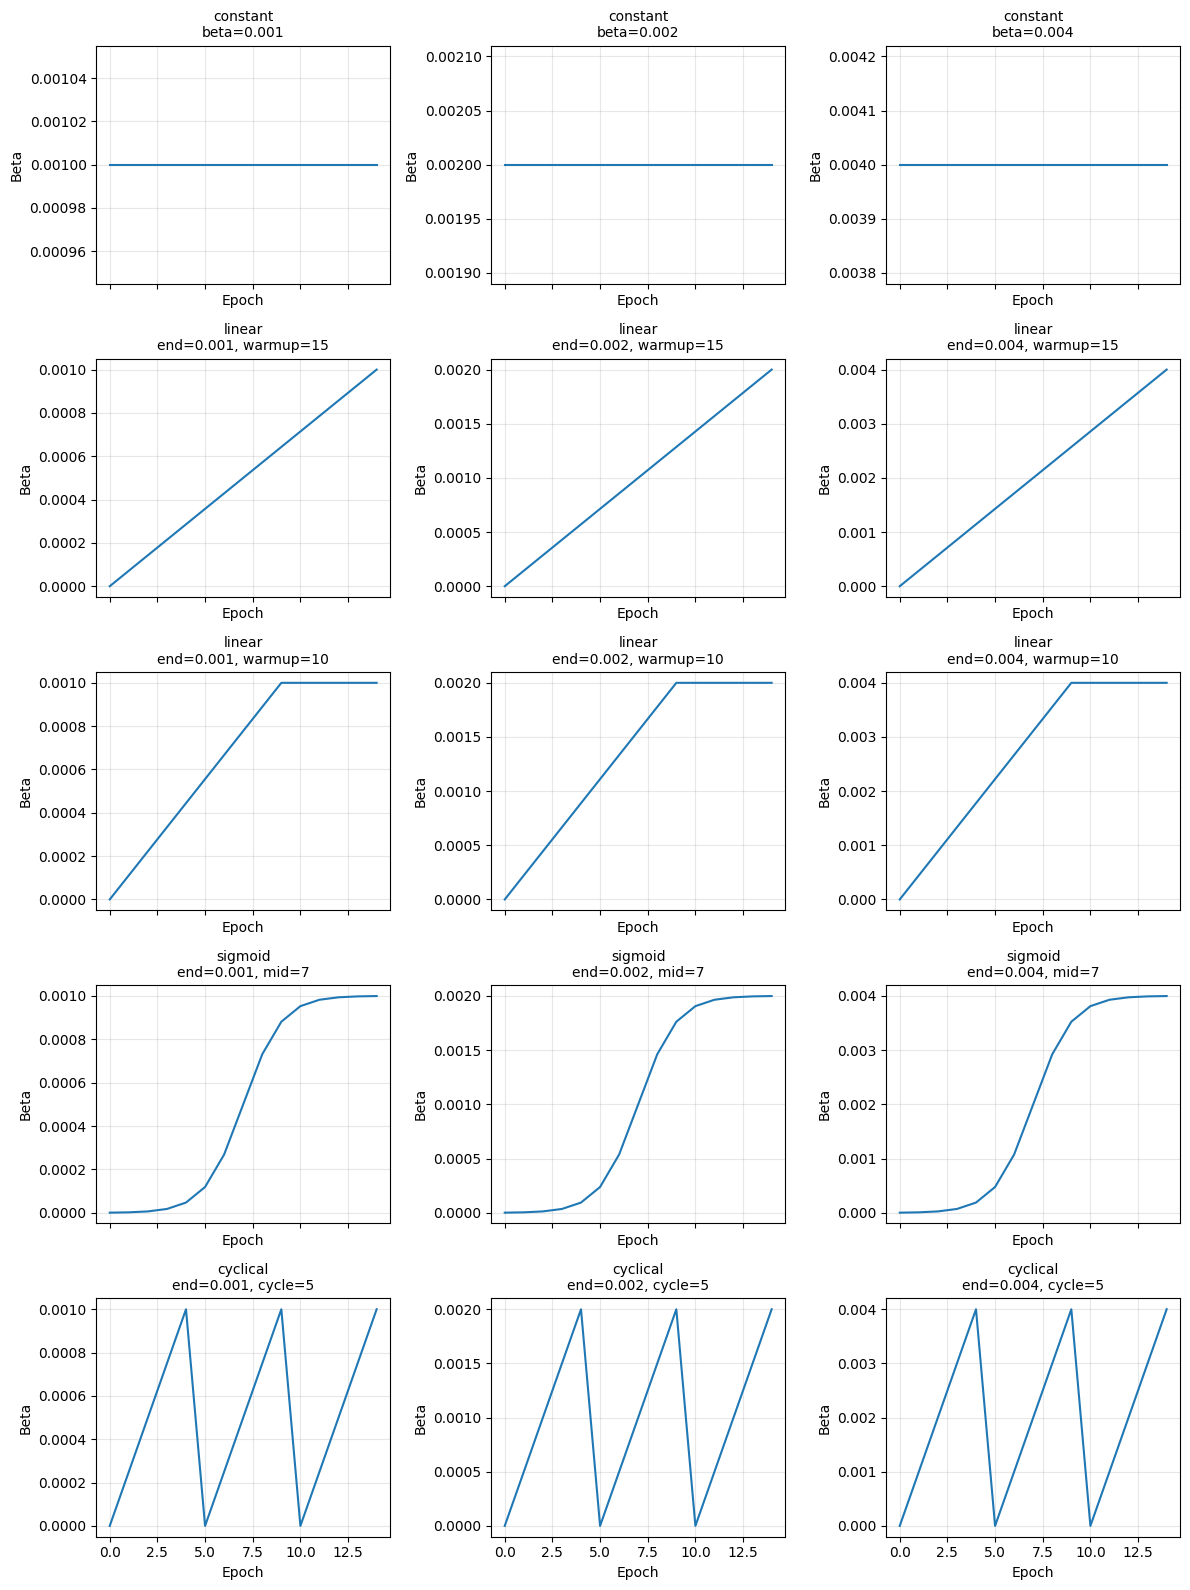

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


N_EPOCHS = 15

base_beta = 1e-03 * 2

beta_configs = [
    {"schedule": "constant", "beta": base_beta / 2},
    {"schedule": "constant", "beta": base_beta},
    {"schedule": "constant", "beta": base_beta * 2},

    {"schedule": "linear_warmup", "start": 0.0, "end": base_beta / 2, "warmup_epochs": 15},
    {"schedule": "linear_warmup", "start": 0.0, "end": base_beta, "warmup_epochs": 15},
    {"schedule": "linear_warmup", "start": 0.0, "end": base_beta * 2, "warmup_epochs": 15},

    {"schedule": "linear_warmup", "start": 0.0, "end": base_beta / 2, "warmup_epochs": 10},
    {"schedule": "linear_warmup", "start": 0.0, "end": base_beta, "warmup_epochs": 10},
    {"schedule": "linear_warmup", "start": 0.0, "end": base_beta * 2, "warmup_epochs": 10},

    {"schedule": "sigmoid_warmup", "start": 0.0, "end": base_beta / 2, "midpoint": 7, "steepness": 1.0},
    {"schedule": "sigmoid_warmup", "start": 0.0, "end": base_beta, "midpoint": 7, "steepness": 1.0},
    {"schedule": "sigmoid_warmup", "start": 0.0, "end": base_beta * 2, "midpoint": 7, "steepness": 1.0},

    {"schedule": "cyclical_linear", "start": 0.0, "end": base_beta / 2, "cycle_length": 5},
    {"schedule": "cyclical_linear", "start": 0.0, "end": base_beta, "cycle_length": 5},
    {"schedule": "cyclical_linear", "start": 0.0, "end": base_beta * 2, "cycle_length": 5},
]


def get_beta_value(epoch, beta_config):
    schedule = beta_config.get("schedule", "constant")

    if schedule == "constant":
        return beta_config.get("beta", 0.01)

    if schedule == "linear_warmup":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        warmup_epochs = beta_config.get("warmup_epochs", 10)
        if warmup_epochs <= 1:
            return end
        alpha = min(epoch / (warmup_epochs - 1), 1.0)
        return start + alpha * (end - start)

    if schedule == "cyclical_linear":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        cycle_length = beta_config.get("cycle_length", 10)
        pos = epoch % cycle_length
        alpha = pos / max(cycle_length - 1, 1)
        return start + alpha * (end - start)

    if schedule == "sigmoid_warmup":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        midpoint = beta_config.get("midpoint", 10)
        steepness = beta_config.get("steepness", 1.0)
        x = (epoch - midpoint) / max(steepness, 1e-8)
        s = 1.0 / (1.0 + np.exp(-x))
        return start + (end - start) * s

    raise ValueError(f"Unknown beta schedule: {schedule}")


def beta_label(cfg):
    s = cfg["schedule"]
    if s == "constant":
        return f"constant\nbeta={cfg['beta']}"
    if s == "linear_warmup":
        return f"linear\nend={cfg['end']}, warmup={cfg['warmup_epochs']}"
    if s == "sigmoid_warmup":
        return f"sigmoid\nend={cfg['end']}, mid={cfg['midpoint']}"
    if s == "cyclical_linear":
        return f"cyclical\nend={cfg['end']}, cycle={cfg['cycle_length']}"
    return s


epochs = np.arange(N_EPOCHS)

n = len(beta_configs)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, cfg in zip(axes, beta_configs):
    betas = [get_beta_value(e, cfg) for e in epochs]
    ax.plot(epochs, betas)
    ax.set_title(beta_label(cfg), fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Beta")
    ax.grid(True, alpha=0.3)

for ax in axes[len(beta_configs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


Training with config: {'model_type': 'vae', 'hidden_dim': 64, 'latent_dim': 128, 'batch_size': 128, 'epochs': 15, 'optimizer_name': 'adam', 'optimizer_params': {'lr': 0.0015}, 'beta_config': {'schedule': 'constant', 'beta': 0.001}}
  Epoch 1/15 - loss: 1.0227 - recon: 1.0227 - kl: 0.0528 - beta: 0.00100
  Epoch 2/15 - loss: 1.0156 - recon: 1.0155 - kl: 0.1158 - beta: 0.00100
  Epoch 3/15 - loss: 0.9986 - recon: 0.9979 - kl: 0.6891 - beta: 0.00100
  Epoch 4/15 - loss: 0.9308 - recon: 0.9297 - kl: 1.1958 - beta: 0.00100
  Epoch 5/15 - loss: 0.8727 - recon: 0.8713 - kl: 1.4337 - beta: 0.00100
  Epoch 6/15 - loss: 0.7895 - recon: 0.7878 - kl: 1.6903 - beta: 0.00100
  Epoch 7/15 - loss: 0.7066 - recon: 0.7048 - kl: 1.8158 - beta: 0.00100
  Epoch 8/15 - loss: 0.6601 - recon: 0.6582 - kl: 1.9658 - beta: 0.00100
  Epoch 9/15 - loss: 0.5788 - recon: 0.5767 - kl: 2.1135 - beta: 0.00100
  Epoch 10/15 - loss: 0.5151 - recon: 0.5128 - kl: 2.2922 - beta: 0.00100
  Epoch 11/15 - loss: 0.5183 - recon

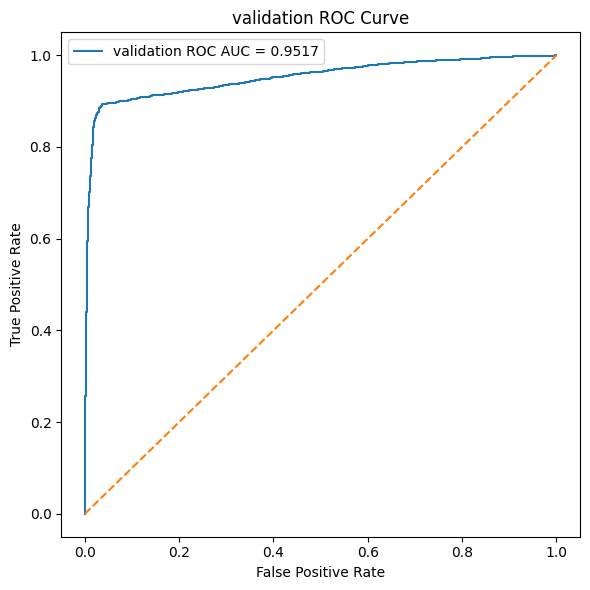

In [ ]:
param_grid = {
    "model_type": ["vae"],
    "hidden_dim": [64],
    "latent_dim": [128],
    "batch_size": [128],
    "epochs": [15],
    "optimizer_name": ["adam"],
    "optimizer_params": [{"lr": 1.5e-3}],
    "beta_config": beta_configs,
}



results_table, model, best_config, best_auc, best_history = grid_search_autoencoder(
    param_grid=param_grid,
    X_train=X_train,
    X_val=X_val,
    y_val=y_val,
)

print(results_table[[
    "model_type", "hidden_dim", "latent_dim", "batch_size",
    "epochs", "optimizer_name", "optimizer_params", "val_auc"
]])

print("\nBest config:", best_config)
print("Best validation AUC:", best_auc)

val_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    ),
    batch_size=best_config["batch_size"] * 2,
    shuffle=False
)

val_scores, y_val_eval = anomaly_scores(
    model,
    val_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    model_type=best_config["model_type"],
)

val_results = evaluate_scores(
    y_val_eval,
    val_scores,
    split_name="validation"
)

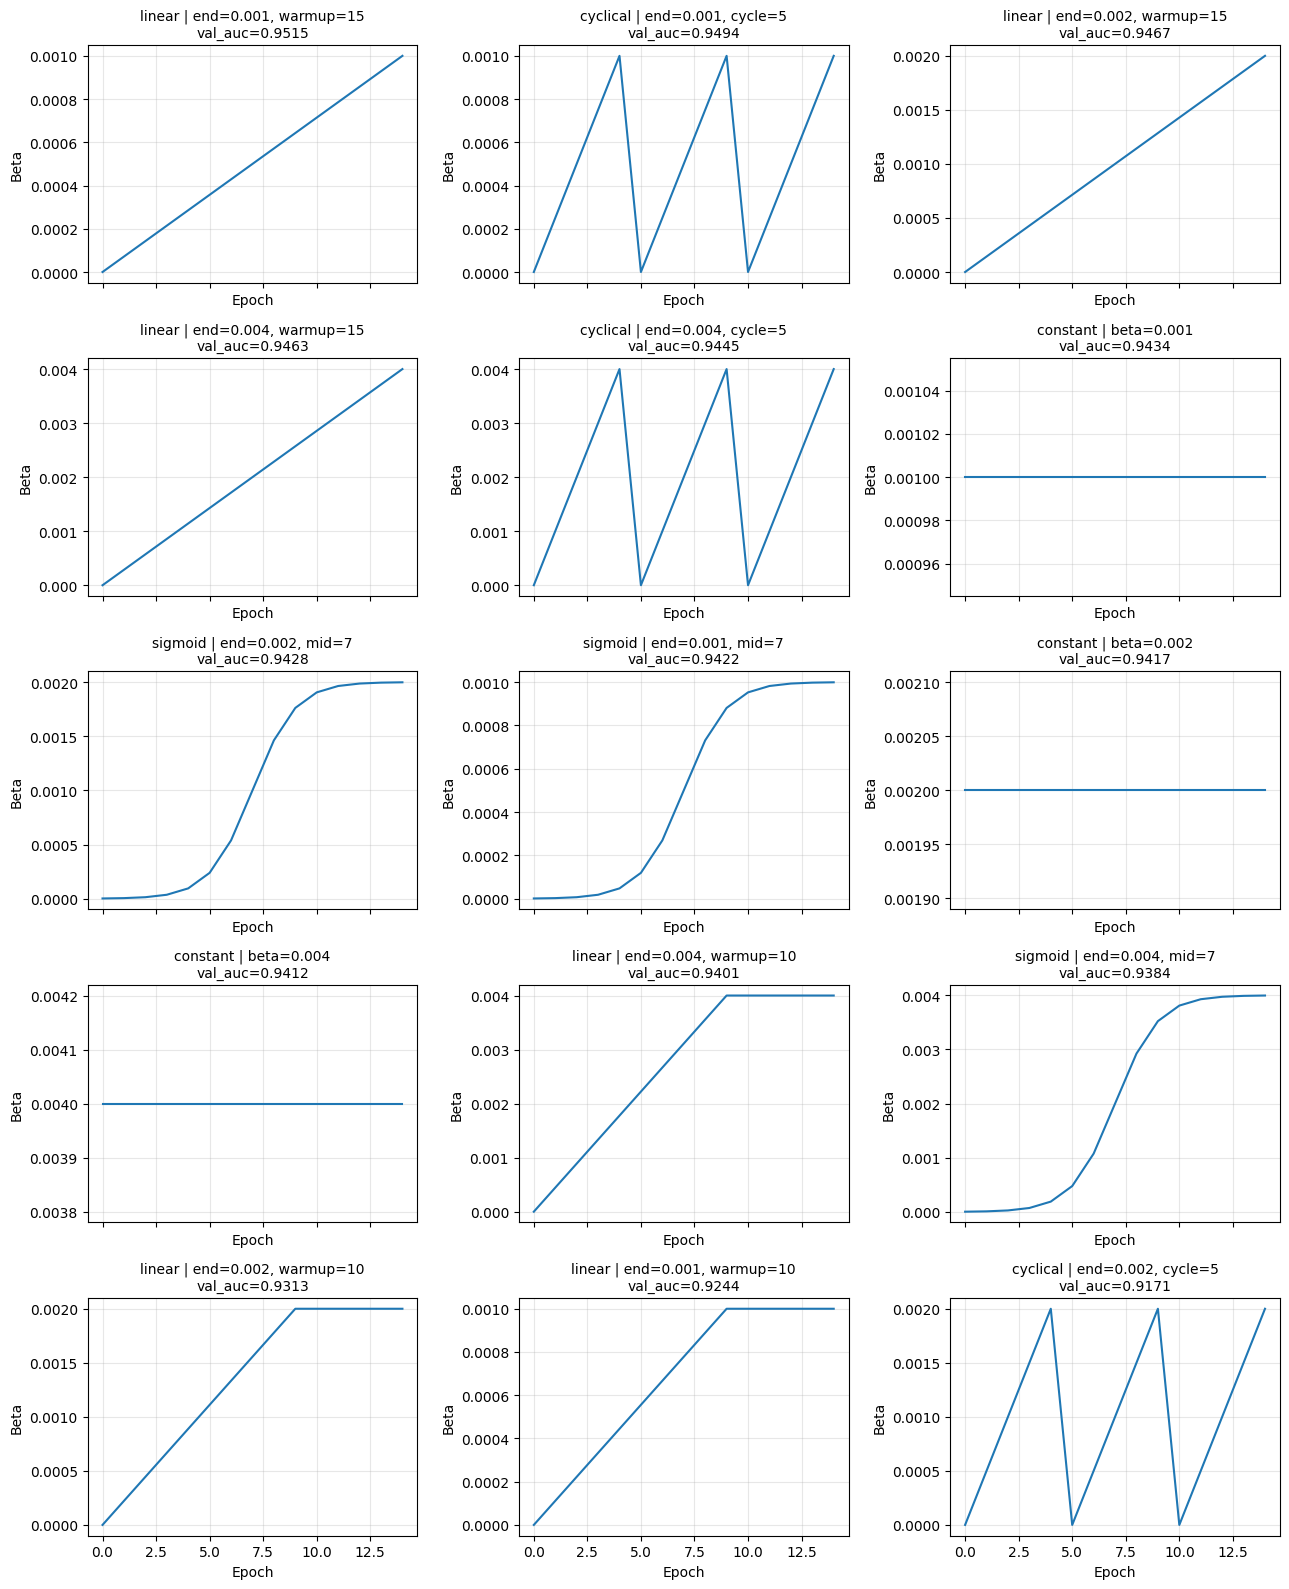

In [ ]:
def get_beta_value(epoch, beta_config):
    schedule = beta_config.get("schedule", "constant")

    if schedule == "constant":
        return beta_config.get("beta", 0.01)

    if schedule == "linear_warmup":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        warmup_epochs = beta_config.get("warmup_epochs", 10)
        if warmup_epochs <= 1:
            return end
        alpha = min(epoch / (warmup_epochs - 1), 1.0)
        return start + alpha * (end - start)

    if schedule == "cyclical_linear":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        cycle_length = beta_config.get("cycle_length", 10)
        pos = epoch % cycle_length
        alpha = pos / max(cycle_length - 1, 1)
        return start + alpha * (end - start)

    if schedule == "sigmoid_warmup":
        start = beta_config.get("start", 0.0)
        end = beta_config.get("end", 0.01)
        midpoint = beta_config.get("midpoint", 10)
        steepness = beta_config.get("steepness", 1.0)
        x = (epoch - midpoint) / max(steepness, 1e-8)
        s = 1.0 / (1.0 + np.exp(-x))
        return start + (end - start) * s

    raise ValueError(f"Unknown beta schedule: {schedule}")


def beta_label(cfg):
    s = cfg["schedule"]
    if s == "constant":
        return f"constant | beta={cfg['beta']}"
    if s == "linear_warmup":
        return f"linear | end={cfg['end']}, warmup={cfg['warmup_epochs']}"
    if s == "sigmoid_warmup":
        return f"sigmoid | end={cfg['end']}, mid={cfg['midpoint']}"
    if s == "cyclical_linear":
        return f"cyclical | end={cfg['end']}, cycle={cfg['cycle_length']}"
    return str(cfg)


rows = results_table.sort_values("val_auc", ascending=False).to_dict("records")

n = len(rows)
ncols = 3
nrows = int(np.ceil(n / ncols))
epochs = np.arange(rows[0]["epochs"])

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, row in zip(axes, rows):
    cfg = row["beta_config"]
    betas = [get_beta_value(e, cfg) for e in epochs]

    ax.plot(epochs, betas)
    ax.set_title(f"{beta_label(cfg)}\nval_auc={row['val_auc']:.4f}", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Beta")
    ax.grid(True, alpha=0.3)

for ax in axes[len(rows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

test threshold: 0.820028
test f1: 0.7796
test auc: 0.9801
test accuracy: 0.9139
Predicted      0     1
Actual                
0          14588  1576
1             72  2914
              precision    recall  f1-score   support

           0     0.9951    0.9025    0.9465     16164
           1     0.6490    0.9759    0.7796      2986

    accuracy                         0.9139     19150
   macro avg     0.8220    0.9392    0.8630     19150
weighted avg     0.9411    0.9139    0.9205     19150



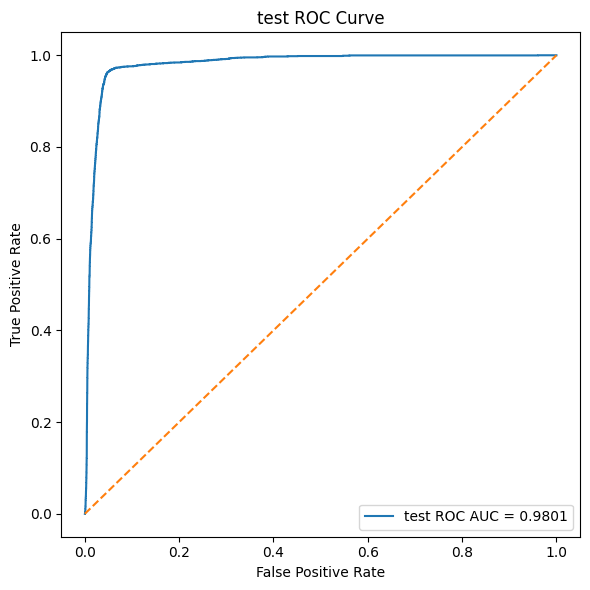

In [ ]:
test_dl = DataLoader(
    TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    ),
    batch_size=best_config["batch_size"] * 2,
    shuffle=False
)

test_scores, y_test_eval = anomaly_scores(
    model,
    test_dl,
    torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    model_type=best_config["model_type"],
)

test_results = evaluate_scores(
    y_test_eval,
    test_scores,
    threshold=val_results["threshold"],
    split_name="test"
)